In [1]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
import yfinance as yf
import joblib
import os
from datetime import datetime, timedelta
from tqdm import tqdm

from sklearn.preprocessing import RobustScaler
from sklearn.metrics import (
    classification_report, confusion_matrix,
    accuracy_score, precision_score, recall_score, f1_score
)
from sklearn.utils.class_weight import compute_class_weight
import lightgbm as lgb

import tensorflow as tf
from tensorflow.keras.models import Model
from tensorflow.keras.layers import (
    Input, LSTM, Dense, Dropout, Bidirectional,
    LayerNormalization, MultiHeadAttention, GlobalAveragePooling1D,
    Concatenate, BatchNormalization
)
from tensorflow.keras.callbacks import (
    EarlyStopping, ReduceLROnPlateau, ModelCheckpoint
)
from tensorflow.keras.optimizers import Adam

try:
    import pandas_ta as ta
    USE_PANDAS_TA = True
    print("✅ pandas_ta chargé")
except ImportError:
    USE_PANDAS_TA = False
    print("⚠️  pandas_ta non disponible — indicateurs de base uniquement")

2026-04-08 13:09:34.836214: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1775653775.099109      55 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1775653775.168601      55 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1775653775.800016      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1775653775.800075      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1775653775.800078      55 computation_placer.cc:177] computation placer alr

⚠️  pandas_ta non disponible — indicateurs de base uniquement


In [14]:
"""
==============================================================================
  MULTI-TICKER ML TRADING MODEL — Advanced Version
  Inspiré des approches LosingLoonies + meilleures pratiques 2024/2025
==============================================================================

ARCHITECTURE :
  - Données : yfinance (multi-ticker)
  - Features : 50+ indicateurs techniques (TA-Lib / pandas-ta)
  - Modèle principal : LSTM Bidirectionnel + Attention
  - Modèle secondaire : LightGBM (gradient boosting, très efficace)
  - Ensemble : vote pondéré LSTM + LGBM
  - Target : classification ternaire (UP / FLAT / DOWN) ou binaire
  - Walk-forward validation (no look-ahead bias)
  - Backtesting avec métriques complètes

INSTALLATION :
  pip install yfinance pandas numpy scikit-learn tensorflow lightgbm
      pandas-ta matplotlib seaborn joblib tqdm
==============================================================================
"""

# Reproductibilité
np.random.seed(42)
tf.random.set_seed(42)

# ─────────────────────────────────────────────────────────────────────────────
# CONFIGURATION GLOBALE
# ─────────────────────────────────────────────────────────────────────────────
CONFIG = {
    # ── Tickers ──────────────────────────────────────────────────────────────
    "TICKERS": [
        # --- TECH & SEMI-CONDUCTEURS (Croissance) ---
        "AAPL", "MSFT", "NVDA", "GOOGL", "META", "AMZN", "TSLA", 
        "AVGO", "ORCL", "ADBE", "ASML", "AMD", "CRM", "INTC",

        # --- FINANCE & BANQUES (Sensibles aux taux) ---
        "JPM", "GS", "BAC", "MS", "V", "MA", "PYPL", "AXP",

        # --- SANTÉ & PHARMA (Défensif) ---
        "LLY", "UNH", "JNJ", "PFE", "ABBV", "MRK", "TMO",

        # --- CONSOMMATION & RETAIL ---
        "WMT", "COST", "PG", "KO", "PEP", "NKE", "SBUX", "EL",

        # --- ÉNERGIE & INDUSTRIE ---
        "XOM", "CVX", "CAT", "GE", "BA", "HON", "LMT",

        # --- LUXE & EUROPE (Tickers avec suffixe si besoin) ---
        "MC.PA", "RMS.PA", "OR.PA", "ASML.AS",  # LVMH, Hermès, L'Oréal

        # --- INDICES & ETFS SECTORIELS (Le "Contexte") ---
        "SPY", "QQQ", "IWM", "DIA", # Marché global
        "XLK", "XLF", "XLV", "XLE", # Tech, Finance, Santé, Énergie
        "GLD", "SLV",               # Or et Argent (Valeurs refuges)
        "TLT",                      # Obligations 20 ans+ (Indispensable pour corrélation taux)

        # --- CRYPTO (Volatilité haute) ---
        "BTC-USD", "ETH-USD", "SOL-USD", "BNB-USD"
    ],

    # ── Données ───────────────────────────────────────────────────────────────
    "START_DATE": "2018-01-01",
    "END_DATE":   datetime.today().strftime("%Y-%m-%d"),
    "INTERVAL":   "1d",          # 1d, 1h, etc.

    # ── Target ────────────────────────────────────────────────────────────────
    "HORIZON":       14,          # prédire dans N jours
    "THRESHOLD":     0.015,      # ±1.5% pour classer UP/DOWN, sinon FLAT
    "BINARY_TARGET": False,      # True → UP/DOWN seulement (ignore FLAT)

    # ── Séquences LSTM ────────────────────────────────────────────────────────
    "LOOKBACK":      60,         # fenêtre temporelle (jours)

    # ── Entraînement ─────────────────────────────────────────────────────────
    "TEST_RATIO":    0.15,
    "VAL_RATIO":     0.10,
    "EPOCHS":        10, # 80 à la base
    "BATCH_SIZE":    512, #64 à la base
    "LR":            1e-3,
    "PATIENCE":      12, #12

    # ── Modèle LSTM ──────────────────────────────────────────────────────────
    "LSTM_UNITS":    [128, 64],
    "DENSE_UNITS":   [64, 32],
    "DROPOUT":       0.3,
    "HEADS":         4,          # têtes d'attention

    # ── LightGBM ─────────────────────────────────────────────────────────────
    "LGBM_PARAMS": {
        "objective":      "multiclass",
        "num_class":      3,
        "n_estimators":   800,
        "learning_rate":  0.03,
        "max_depth":      6,
        "num_leaves":     63,
        "subsample":      0.8,
        "colsample_bytree": 0.8,
        "reg_alpha":      0.1,
        "reg_lambda":     0.1,
        "min_child_samples": 20,
        "verbose":        -1,
    },

    # ── Ensemble ─────────────────────────────────────────────────────────────
    "LSTM_WEIGHT": 0.45,
    "LGBM_WEIGHT": 0.55,

    # ── Backtesting ──────────────────────────────────────────────────────────
    "INITIAL_CAPITAL": 10_000,
    "POSITION_SIZE":   0.10,     # 10 % du capital par trade

    # ── Sauvegarde ───────────────────────────────────────────────────────────
    "MODEL_DIR": "./saved_models",
}

os.makedirs(CONFIG["MODEL_DIR"], exist_ok=True)
N_CLASSES = 2 if CONFIG["BINARY_TARGET"] else 3


# ─────────────────────────────────────────────────────────────────────────────
# 1. TÉLÉCHARGEMENT DES DONNÉES
# ─────────────────────────────────────────────────────────────────────────────
def download_data(tickers: list, start: str, end: str, interval: str) -> dict:
    """Télécharge les OHLCV pour chaque ticker."""
    data = {}
    print("\n📥 Téléchargement des données...")
    for ticker in tqdm(tickers):
        try:
            df = yf.download(ticker, start=start, end=end,
                             interval=interval, auto_adjust=True, progress=False)
            if len(df) > 200:
                df.columns = [c[0] if isinstance(c, tuple) else c for c in df.columns]
                df.dropna(inplace=True)
                data[ticker] = df
                print(f"  ✅ {ticker} : {len(df)} barres")
            else:
                print(f"  ⚠️  {ticker} : données insuffisantes ({len(df)} lignes)")
        except Exception as e:
            print(f"  ❌ {ticker} : erreur — {e}")
    return data



print("=" * 60)
print("  🚀 MULTI-TICKER ML TRADING MODEL")
print("=" * 60)

# ── 1. Données ────────────────────────────────────────────────────────────
raw_data = download_data(
    CONFIG["TICKERS"], CONFIG["START_DATE"],
    CONFIG["END_DATE"], CONFIG["INTERVAL"]
)

  🚀 MULTI-TICKER ML TRADING MODEL

📥 Téléchargement des données...


  3%|▎         | 2/63 [00:00<00:04, 14.32it/s]

  ✅ AAPL : 2076 barres
  ✅ MSFT : 2076 barres


  6%|▋         | 4/63 [00:00<00:03, 15.62it/s]

  ✅ NVDA : 2076 barres
  ✅ GOOGL : 2076 barres


...

 90%|█████████ | 57/63 [00:02<00:00, 21.87it/s]

  ✅ XLK : 2076 barres
  ✅ XLF : 2076 barres
  ✅ XLV : 2076 barres
  ✅ XLE : 2076 barres
  ✅ GLD : 2076 barres


100%|██████████| 63/63 [00:02<00:00, 23.74it/s]

  ✅ SLV : 2076 barres
  ✅ TLT : 2076 barres
  ✅ BTC-USD : 3019 barres
  ✅ ETH-USD : 3019 barres
  ✅ SOL-USD : 2189 barres
  ✅ BNB-USD : 3019 barres


100%|██████████| 63/63 [00:02<00:00, 21.48it/s]


🔧 Feature engineering: 100%|██████████| 63/63 [02:50<00:00,  2.71s/it]



✅ Dataset combiné : 121348 lignes, 92 colonnes
🧹 Nettoyage des valeurs infinies et NaN par ticker...
  📐 Nombre de features : 90

📊 Split : Train=91011, Val=12134, Test=18203

  Distribution des classes (train) :
    Classe 0 : 47501 (52.2%)
    Classe 1 : 43510 (47.8%)

  📊 Entraînement LightGBM

  LightGBM — Test
  Accuracy  : 0.5699
  Precision : 0.4764
  Recall    : 0.0543
  F1-Score  : 0.0975
              precision    recall  f1-score   support

           0       0.57      0.96      0.72     10416
           1       0.48      0.05      0.10      7787

    accuracy                           0.57     18203
   macro avg       0.53      0.50      0.41     18203
weighted avg       0.53      0.57      0.45     18203



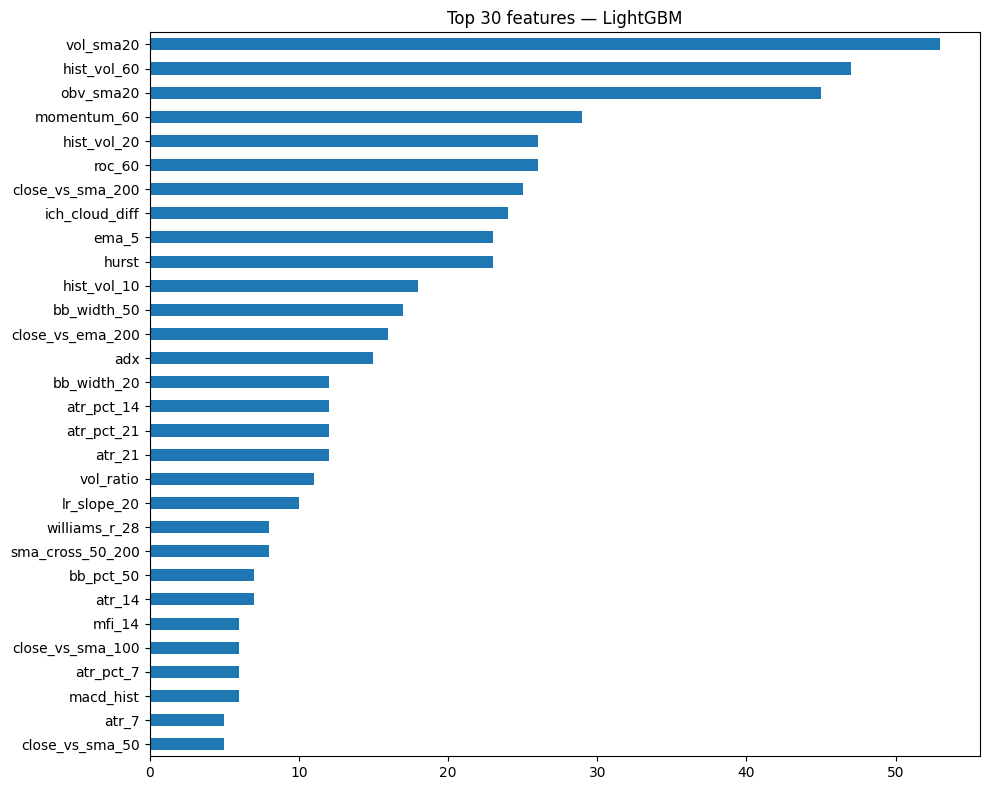


  🧠 Entraînement LSTM Bidirectionnel + Attention


Model: "BiLSTM_Attention"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_seq           │ (None, 60, 90)    │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bilstm_1            │ (None, 60, 256)   │    224,256 │ input_seq[0][0]   │
│ (Bidirectional)     │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 60, 256)   │        512 │ bilstm_1[0][0]    │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_25          │ (None, 60, 256)   │          0 │ layer_normalizat… │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bilstm_2            │ (None, 60, 128)   │    164,352 │ dropout_25[0][0]  │
│ (Bidirectional)     │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 60, 128)   │        256 │ bilstm_2[0][0]    │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_26          │ (None, 60, 128)   │          0 │ layer_normalizat… │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ mha                 │ (None, 60, 128)   │     66,048 │ dropout_26[0][0], │
│ (MultiHeadAttentio… │                   │            │ dropout_26[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_5 (Add)         │ (None, 60, 128)   │          0 │ mha[0][0],        │
│                     │                   │            │ dropout_26[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 60, 128)   │        256 │ add_5[0][0]       │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_average_poo… │ (None, 128)       │          0 │ layer_normalizat… │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_10 (Dense)    │ (None, 64)        │      8,256 │ global_average_p… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 64)        │        256 │ dense_10[0][0]    │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_28          │ (None, 64)        │          0 │ batch_normalizat… │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_11 (Dense)    │ (None, 32)        │      2,080 │ dropout_28[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 32)        │        128 │ dense_11[0][0]    │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_29          │ (None, 32)        │          0 │ batch_normalizat… │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼─────────────────

 Total params: 466,433 (1.78 MB)

 Trainable params: 466,241 (1.78 MB)

 Non-trainable params: 192 (768.00 B)

Epoch 1/10
178/178 ━━━━━━━━━━━━━━━━━━━━ 65s 287ms/step - accuracy: 0.5539 - loss: 0.7280 - val_accuracy: 0.4583 - val_loss: 0.7508 - learning_rate: 0.0010
Epoch 2/10
178/178 ━━━━━━━━━━━━━━━━━━━━ 49s 276ms/step - accuracy: 0.6409 - loss: 0.6366 - val_accuracy: 0.4481 - val_loss: 0.7848 - learning_rate: 0.0010
Epoch 3/10
178/178 ━━━━━━━━━━━━━━━━━━━━ 49s 273ms/step - accuracy: 0.6658 - loss: 0.6108 - val_accuracy: 0.4958 - val_loss: 0.7704 - learning_rate: 0.0010
Epoch 4/10
178/178 ━━━━━━━━━━━━━━━━━━━━ 50s 278ms/step - accuracy: 0.6742 - loss: 0.5991 - val_accuracy: 0.5261 - val_loss: 0.7344 - learning_rate: 0.0010
Epoch 5/10
178/178 ━━━━━━━━━━━━━━━━━━━━ 50s 278ms/step - accuracy: 0.6838 - loss: 0.5914 - val_accuracy: 0.5281 - val_loss: 0.7220 - learning_rate: 0.0010
Epoch 6/10
178/178 ━━━━━━━━━━━━━━━━━━━━ 49s 275ms/step - accuracy: 0.6859 - loss: 0.5866 - val_accuracy: 0.5105 - val_loss: 0.7335 - learning_rate: 0.0010
Epoch 7/10
178/178 ━━━━━━━━━━━━━━━━━━━━ 49s 273ms/step - accuracy: 0.6

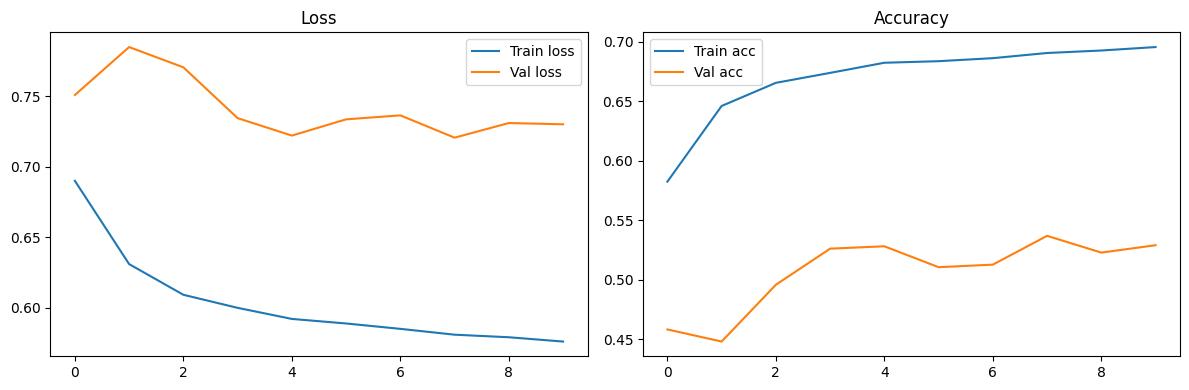


  LSTM BiDirectionnel — Test
  Accuracy  : 0.5380
  Precision : 0.4380
  Recall    : 0.2828
  F1-Score  : 0.3437
              precision    recall  f1-score   support

           0       0.58      0.73      0.64     10416
           1       0.44      0.28      0.34      7787

    accuracy                           0.54     18203
   macro avg       0.51      0.51      0.49     18203
weighted avg       0.52      0.54      0.52     18203


  🏆 ENSEMBLE — Test
  Accuracy  : 0.4427
  Precision : 0.4241
  Recall    : 0.8341
  F1-Score  : 0.5623
              precision    recall  f1-score   support

           0       0.54      0.15      0.23     10356
           1       0.42      0.83      0.56      7787

    accuracy                           0.44     18143
   macro avg       0.48      0.49      0.40     18143
weighted avg       0.49      0.44      0.37     18143



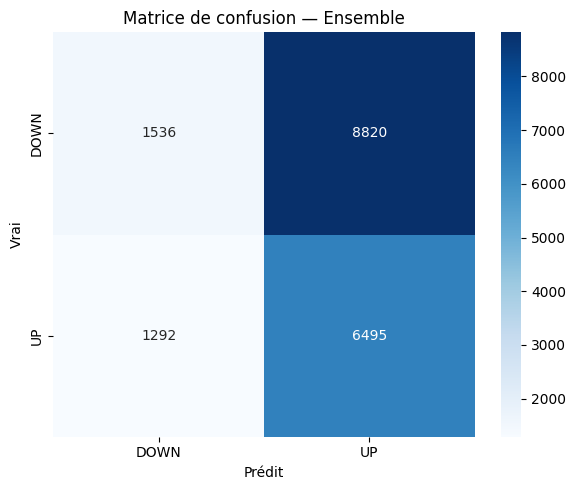


  📈 Backtest

  BACKTEST RÉSULTATS
  Capital initial  : $10,000
  Capital final    : $4,647
  Rendement total  : -53.53%
  Sharpe (approx.) : -0.096
  Max Drawdown     : -98.59%
  Win Rate         : 49.6%
  Trades effectués : 2828


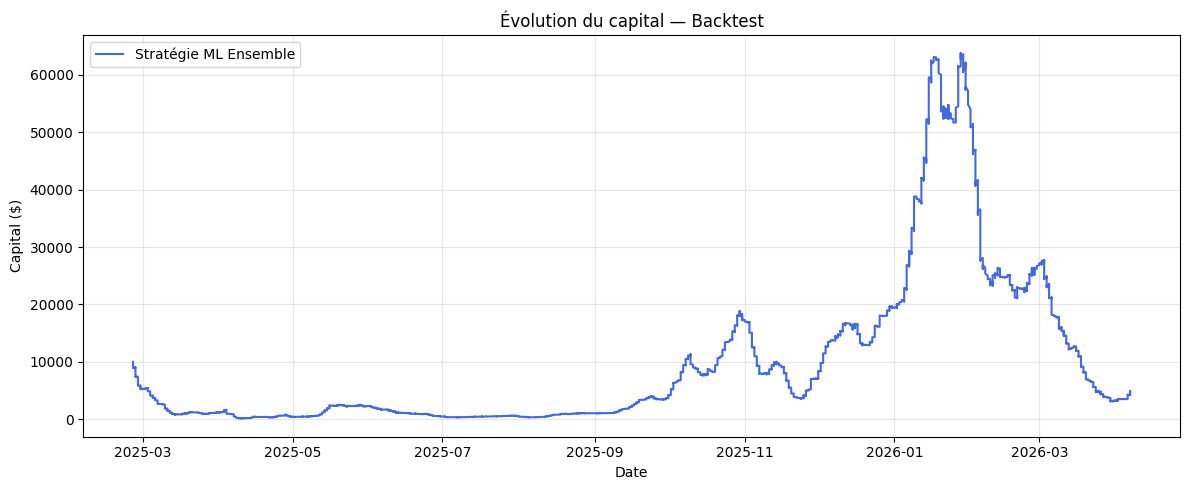


  🔮 Prédictions sur données récentes

🔮 Prédiction pour AAPL...
  Prédiction (14j)  : 📉 DOWN
  Probabilités        : {'📉 DOWN': np.float64(0.504), '📈 UP': np.float64(0.496)}

🔮 Prédiction pour NVDA...
  Prédiction (14j)  : 📈 UP
  Probabilités        : {'📉 DOWN': np.float64(0.476), '📈 UP': np.float64(0.524)}

🔮 Prédiction pour SPY...
  Prédiction (14j)  : 📉 DOWN
  Probabilités        : {'📉 DOWN': np.float64(0.532), '📈 UP': np.float64(0.468)}

🔮 Prédiction pour BTC-USD...
  Prédiction (14j)  : 📉 DOWN
  Probabilités        : {'📉 DOWN': np.float64(0.646), '📈 UP': np.float64(0.354)}

✅ Modèles sauvegardés dans ./saved_models/

🎉 Pipeline terminé avec succès !


In [17]:
# ─────────────────────────────────────────────────────────────────────────────
# 2. FEATURE ENGINEERING — 50+ INDICATEURS
# ─────────────────────────────────────────────────────────────────────────────
def add_indicators(df: pd.DataFrame) -> pd.DataFrame:
    """Ajoute tous les indicateurs techniques."""
    df = df.copy()
    close = df["Close"]
    high  = df["High"]
    low   = df["Low"]
    vol   = df["Volume"]
    open_ = df["Open"]

    # ── Prix / Returns ────────────────────────────────────────────────────────
    for n in [1, 2, 3, 5, 10, 20]:
        df[f"ret_{n}d"]  = close.pct_change(n)
        df[f"logret_{n}d"] = np.log(close / close.shift(n))
    df["hl_ratio"]   = (high - low) / close
    df["oc_ratio"]   = (close - open_) / open_
    df["gap"]        = (open_ - close.shift(1)) / close.shift(1)

    # ── Moyennes mobiles ─────────────────────────────────────────────────────
    for w in [5, 10, 20, 50, 100, 200]:
        df[f"sma_{w}"]   = close.rolling(w).mean()
        df[f"ema_{w}"]   = close.ewm(span=w, adjust=False).mean()
        df[f"close_vs_sma_{w}"] = (close - df[f"sma_{w}"]) / df[f"sma_{w}"]
        df[f"close_vs_ema_{w}"] = (close - df[f"ema_{w}"]) / df[f"ema_{w}"]

    # Crossovers
    df["sma_cross_5_20"]   = (df["sma_5"] > df["sma_20"]).astype(int)
    df["sma_cross_20_50"]  = (df["sma_20"] > df["sma_50"]).astype(int)
    df["sma_cross_50_200"] = (df["sma_50"] > df["sma_200"]).astype(int)  # Golden/Death Cross
    df["ema_cross_12_26"]  = (df["ema_10"] > df["ema_20"]).astype(int)

    # ── RSI ───────────────────────────────────────────────────────────────────
    for period in [7, 14, 21]:
        delta  = close.diff()
        gain   = delta.clip(lower=0).rolling(period).mean()
        loss   = (-delta.clip(upper=0)).rolling(period).mean()
        rs     = gain / (loss + 1e-10)
        df[f"rsi_{period}"] = 100 - (100 / (1 + rs))
    df["rsi_slope"] = df["rsi_14"].diff(3)

    # ── MACD ─────────────────────────────────────────────────────────────────
    ema12 = close.ewm(span=12, adjust=False).mean()
    ema26 = close.ewm(span=26, adjust=False).mean()
    df["macd"]        = ema12 - ema26
    df["macd_signal"] = df["macd"].ewm(span=9, adjust=False).mean()
    df["macd_hist"]   = df["macd"] - df["macd_signal"]
    df["macd_cross"]  = (df["macd"] > df["macd_signal"]).astype(int)

    # ── Bollinger Bands ───────────────────────────────────────────────────────
    for w in [20, 50]:
        mid = close.rolling(w).mean()
        std = close.rolling(w).std()
        df[f"bb_upper_{w}"] = mid + 2 * std
        df[f"bb_lower_{w}"] = mid - 2 * std
        df[f"bb_width_{w}"] = (df[f"bb_upper_{w}"] - df[f"bb_lower_{w}"]) / mid
        df[f"bb_pct_{w}"]   = (close - df[f"bb_lower_{w}"]) / (
            df[f"bb_upper_{w}"] - df[f"bb_lower_{w}"] + 1e-10)

    # ── ATR & Volatilité ─────────────────────────────────────────────────────
    tr = pd.concat([
        high - low,
        (high - close.shift()).abs(),
        (low  - close.shift()).abs()
    ], axis=1).max(axis=1)
    for w in [7, 14, 21]:
        df[f"atr_{w}"]      = tr.rolling(w).mean()
        df[f"atr_pct_{w}"]  = df[f"atr_{w}"] / close
    df["hist_vol_10"]  = df["logret_1d"].rolling(10).std() * np.sqrt(252)
    df["hist_vol_20"]  = df["logret_1d"].rolling(20).std() * np.sqrt(252)
    df["hist_vol_60"]  = df["logret_1d"].rolling(60).std() * np.sqrt(252)
    df["vol_ratio"]    = df["hist_vol_10"] / (df["hist_vol_60"] + 1e-10)

    # ── Stochastique ─────────────────────────────────────────────────────────
    for k_period in [9, 14]:
        low_k  = low.rolling(k_period).min()
        high_k = high.rolling(k_period).max()
        df[f"stoch_k_{k_period}"] = 100 * (close - low_k) / (high_k - low_k + 1e-10)
        df[f"stoch_d_{k_period}"] = df[f"stoch_k_{k_period}"].rolling(3).mean()

    # ── Williams %R ──────────────────────────────────────────────────────────
    for w in [14, 28]:
        highest_high = high.rolling(w).max()
        lowest_low   = low.rolling(w).min()
        df[f"williams_r_{w}"] = -100 * (highest_high - close) / (
            highest_high - lowest_low + 1e-10)

    # ── CCI ───────────────────────────────────────────────────────────────────
    for w in [14, 20]:
        tp = (high + low + close) / 3
        df[f"cci_{w}"] = (tp - tp.rolling(w).mean()) / (
            0.015 * tp.rolling(w).apply(lambda x: np.mean(np.abs(x - x.mean()))))

    # ── MFI (Money Flow Index) ────────────────────────────────────────────────
    tp     = (high + low + close) / 3
    mf     = tp * vol
    pos_mf = mf.where(tp > tp.shift(1), 0)
    neg_mf = mf.where(tp < tp.shift(1), 0)
    for w in [14]:
        mfr = pos_mf.rolling(w).sum() / (neg_mf.rolling(w).sum() + 1e-10)
        df[f"mfi_{w}"] = 100 - (100 / (1 + mfr))

    # ── OBV & Volume features ─────────────────────────────────────────────────
    df["obv"]        = (np.sign(close.diff()) * vol).fillna(0).cumsum()
    df["obv_sma20"]  = df["obv"].rolling(20).mean()
    df["obv_slope"]  = df["obv"].diff(5) / (df["obv"].abs().rolling(5).mean() + 1)
    df["vol_sma20"]  = vol.rolling(20).mean()
    df["vol_ratio_20"] = vol / (df["vol_sma20"] + 1)
    df["vol_spike"]  = (vol > df["vol_sma20"] * 2).astype(int)
    for w in [5, 10, 20]:
        df[f"vol_pct_{w}"] = vol.pct_change(w)

    # ── VWAP approx (daily reset non dispo, on utilise rolling) ──────────────
    dollar_vol   = close * vol
    df["vwap_20"] = dollar_vol.rolling(20).sum() / (vol.rolling(20).sum() + 1)
    df["close_vs_vwap"] = (close - df["vwap_20"]) / df["vwap_20"]

    # ── Ichimoku ──────────────────────────────────────────────────────────────
    df["ich_tenkan"] = (high.rolling(9).max()  + low.rolling(9).min())  / 2
    df["ich_kijun"]  = (high.rolling(26).max() + low.rolling(26).min()) / 2
    df["ich_senkou_a"] = (df["ich_tenkan"] + df["ich_kijun"]) / 2
    df["ich_senkou_b"] = (high.rolling(52).max() + low.rolling(52).min()) / 2
    df["ich_cloud_diff"] = df["ich_senkou_a"] - df["ich_senkou_b"]
    df["above_cloud"]  = (close > df[["ich_senkou_a","ich_senkou_b"]].max(axis=1)).astype(int)

    # ── Donchian ─────────────────────────────────────────────────────────────
    for w in [20, 55]:
        df[f"donchian_high_{w}"] = high.rolling(w).max()
        df[f"donchian_low_{w}"]  = low.rolling(w).min()
        df[f"donchian_pos_{w}"]  = (close - df[f"donchian_low_{w}"]) / (
            df[f"donchian_high_{w}"] - df[f"donchian_low_{w}"] + 1e-10)

    # ── Momentum / ROC ────────────────────────────────────────────────────────
    for n in [5, 10, 20, 60]:
        df[f"roc_{n}"]      = close.pct_change(n) * 100
        df[f"momentum_{n}"] = close - close.shift(n)

    # ── ADX (Average Directional Index) ──────────────────────────────────────
    high_diff = high.diff()
    low_diff  = low.diff()
    plus_dm   = high_diff.where((high_diff > low_diff.abs()) & (high_diff > 0), 0)
    minus_dm  = low_diff.abs().where((low_diff.abs() > high_diff) & (low_diff < 0), 0)
    tr14      = tr.rolling(14).mean()
    plus_di   = 100 * (plus_dm.rolling(14).mean() / (tr14 + 1e-10))
    minus_di  = 100 * (minus_dm.rolling(14).mean() / (tr14 + 1e-10))
    dx        = 100 * (plus_di - minus_di).abs() / (plus_di + minus_di + 1e-10)
    df["adx"]      = dx.rolling(14).mean()
    df["plus_di"]  = plus_di
    df["minus_di"] = minus_di
    df["adx_trend"] = (df["adx"] > 25).astype(int)

    # ── Chandelier Exit ───────────────────────────────────────────────────────
    df["chandelier_long"]  = high.rolling(22).max() - 3 * df["atr_14"]
    df["chandelier_short"] = low.rolling(22).min()  + 3 * df["atr_14"]
    df["above_chandelier"] = (close > df["chandelier_long"]).astype(int)

    # ── Supertrend (simplifié) ────────────────────────────────────────────────
    factor = 3.0
    hl2    = (high + low) / 2
    df["supertrend_up"]   = hl2 - factor * df["atr_14"]
    df["supertrend_down"] = hl2 + factor * df["atr_14"]
    # Position relative
    df["above_supertrend_up"]   = (close > df["supertrend_up"]).astype(int)
    df["below_supertrend_down"] = (close < df["supertrend_down"]).astype(int)

    # ── Linear Regression Slope ───────────────────────────────────────────────
    def lr_slope(series, w):
        def _slope(x):
            if len(x) < 2:
                return np.nan
            return np.polyfit(range(len(x)), x, 1)[0]
        return series.rolling(w).apply(_slope, raw=True)

    df["lr_slope_10"] = lr_slope(close, 10) / close
    df["lr_slope_20"] = lr_slope(close, 20) / close

    # ── Hurst Exponent (approx) ───────────────────────────────────────────────
    def hurst_approx(series, lag=20):
        def _hurst(x):
            lags = range(2, min(lag, len(x) // 2))
            tau  = [np.std(np.subtract(x[l:], x[:-l])) for l in lags]
            if len(tau) < 2 or np.std(tau) == 0:
                return 0.5
            try:
                poly = np.polyfit(np.log(list(lags)), np.log(tau), 1)
                return poly[0]
            except:
                return 0.5
        return series.rolling(40).apply(_hurst, raw=True)

    df["hurst"] = hurst_approx(close)

    # ── pandas_ta supplémentaires ─────────────────────────────────────────────
    if USE_PANDAS_TA:
        df.ta.squeeze(append=True)      # TTM Squeeze
        df.ta.psar(append=True)         # Parabolic SAR
        df.ta.kc(append=True)           # Keltner Channel

    # ── Normalisation interne (scale-free) ───────────────────────────────────
    # Tous les prix sont déjà en ratios/%, les volumes aussi

    return df


def compute_target(df: pd.DataFrame, horizon: int, threshold: float,
                   binary: bool) -> pd.Series:
    """
    Calcule le label :
      Binary  : 1 si close[+horizon] > close*(1+th), sinon 0
      Ternaire: 2=UP, 0=DOWN, 1=FLAT
    """
    fwd_ret = df["Close"].pct_change(horizon).shift(-horizon)
    if binary:
        return (fwd_ret > threshold).astype(int)
    else:
        conditions = [
            fwd_ret >  threshold,
            fwd_ret < -threshold,
        ]
        return pd.Series(
            np.select(conditions, [2, 0], default=1),
            index=df.index
        )


# ─────────────────────────────────────────────────────────────────────────────
# 3. PRÉPARATION DES DONNÉES MULTI-TICKER
# ─────────────────────────────────────────────────────────────────────────────
def prepare_all_tickers(raw_data: dict, cfg: dict):
    """
    Pour chaque ticker :
      1. Calcule les indicateurs
      2. Calcule le target
      3. Nettoie les NaN
    Retourne un DataFrame concaténé avec une colonne 'ticker'.
    """
    frames = []
    for ticker, df in tqdm(raw_data.items(), desc="🔧 Feature engineering"):
        feat = add_indicators(df)
        feat["target"] = compute_target(
            feat, cfg["HORIZON"], cfg["THRESHOLD"], cfg["BINARY_TARGET"]
        )
        feat["ticker"] = ticker
        feat.dropna(inplace=True)
        # Supprimer les colonnes de prix bruts (éviter le look-ahead)
        price_cols = ["Open","High","Low","Close","Volume",
                      "ich_tenkan","ich_kijun","ich_senkou_a","ich_senkou_b",
                      "chandelier_long","chandelier_short",
                      "supertrend_up","supertrend_down",
                      "vwap_20", "obv","donchian_high_20","donchian_high_55",
                      "donchian_low_20","donchian_low_55",
                      "sma_5","sma_10","sma_20","sma_50","sma_100","sma_200",
                      "ema_10","ema_20","ema_50","ema_100","ema_200",
                      "bb_upper_20","bb_lower_20","bb_upper_50","bb_lower_50",
                      "macd","macd_signal",
                      "plus_di","minus_di",
                      "chandelier_long","chandelier_short",
                      "lr_slope_10", "lr_slope_20",  # keep? ratio form ok
                      ]
        # On garde lr_slope (normalisé) et on drop les colonnes de prix bruts seulement
        keep_drop = [c for c in price_cols if c in feat.columns
                     and c not in ["lr_slope_10","lr_slope_20"]]
        feat.drop(columns=keep_drop, errors="ignore", inplace=True)
        frames.append(feat)

    combined = pd.concat(frames).sort_index()
    print(f"\n✅ Dataset combiné : {combined.shape[0]} lignes, "
          f"{combined.shape[1]} colonnes")
    return combined


def get_feature_columns(df: pd.DataFrame) -> list:
    exclude = {"target", "ticker"}
    return [c for c in df.columns if c not in exclude]


# ─────────────────────────────────────────────────────────────────────────────
# 4. SPLIT TEMPOREL (walk-forward, pas de data leakage)
# ─────────────────────────────────────────────────────────────────────────────
def temporal_split(df: pd.DataFrame, val_ratio: float, test_ratio: float):
    """Split basé sur le temps (pas random)."""
    n = len(df)
    train_end = int(n * (1 - val_ratio - test_ratio))
    val_end   = int(n * (1 - test_ratio))
    train = df.iloc[:train_end]
    val   = df.iloc[train_end:val_end]
    test  = df.iloc[val_end:]
    print(f"\n📊 Split : Train={len(train)}, Val={len(val)}, Test={len(test)}")
    return train, val, test


# ─────────────────────────────────────────────────────────────────────────────
# 5. SCALERS
# ─────────────────────────────────────────────────────────────────────────────
def fit_scalers(train_df: pd.DataFrame, feat_cols: list):
    """RobustScaler (résistant aux outliers)."""
    scaler = RobustScaler()
    scaler.fit(train_df[feat_cols])
    return scaler


def scale_data(df: pd.DataFrame, feat_cols: list, scaler) -> np.ndarray:
    return scaler.transform(df[feat_cols])


# ─────────────────────────────────────────────────────────────────────────────
# 6. SÉQUENCES LSTM
# ─────────────────────────────────────────────────────────────────────────────
def make_sequences(X: np.ndarray, y: np.ndarray,
                   lookback: int) -> tuple[np.ndarray, np.ndarray]:
    """Crée des séquences de longueur lookback."""
    Xs, ys = [], []
    for i in range(lookback, len(X)):
        Xs.append(X[i - lookback:i])
        ys.append(y[i])
    return np.array(Xs), np.array(ys)


# ─────────────────────────────────────────────────────────────────────────────
# 7. MODÈLE LSTM BIDIRECTIONNEL + ATTENTION
# ─────────────────────────────────────────────────────────────────────────────
def build_lstm_model(lookback: int, n_features: int,
                     n_classes: int, cfg: dict) -> Model:
    """
    Architecture :
      BiLSTM (128) → BiLSTM (64) → Multi-Head Attention → Dense → Output
    """
    inp = Input(shape=(lookback, n_features), name="input_seq")

    # ── LSTM layers ──────────────────────────────────────────────────────────
    x = Bidirectional(
        LSTM(cfg["LSTM_UNITS"][0], return_sequences=True, dropout=0.1,
             recurrent_dropout=0.1),
        name="bilstm_1"
    )(inp)
    x = LayerNormalization()(x)
    x = Dropout(cfg["DROPOUT"])(x)

    x = Bidirectional(
        LSTM(cfg["LSTM_UNITS"][1], return_sequences=True, dropout=0.1),
        name="bilstm_2"
    )(x)
    x = LayerNormalization()(x)
    x = Dropout(cfg["DROPOUT"])(x)

    # ── Multi-Head Attention ──────────────────────────────────────────────────
    attn_out = MultiHeadAttention(
        num_heads=cfg["HEADS"],
        key_dim=cfg["LSTM_UNITS"][1] * 2 // cfg["HEADS"],
        name="mha"
    )(x, x)
    attn_out = LayerNormalization()(attn_out + x)  # Residual
    x = GlobalAveragePooling1D()(attn_out)

    # ── Dense layers ─────────────────────────────────────────────────────────
    for units in cfg["DENSE_UNITS"]:
        x = Dense(units, activation="relu")(x)
        x = BatchNormalization()(x)
        x = Dropout(cfg["DROPOUT"] / 2)(x)

    # ── Output ────────────────────────────────────────────────────────────────
    activation = "softmax" if n_classes > 2 else "sigmoid"
    out = Dense(n_classes if n_classes > 2 else 1,
                activation=activation, name="output")(x)

    model = Model(inputs=inp, outputs=out, name="BiLSTM_Attention")
    return model


# ─────────────────────────────────────────────────────────────────────────────
# 8. ENTRAÎNEMENT LSTM
# ─────────────────────────────────────────────────────────────────────────────
def train_lstm(X_tr, y_tr, X_val, y_val, n_features: int, cfg: dict, n_classes: int):
    """Entraîne le modèle LSTM."""
    # Séquences
    X_tr_seq,  y_tr_seq  = make_sequences(X_tr,  y_tr,  cfg["LOOKBACK"])
    X_val_seq, y_val_seq = make_sequences(X_val, y_val, cfg["LOOKBACK"])

    # Poids de classe
    class_w = compute_class_weight("balanced",
                                    classes=np.unique(y_tr_seq),
                                    y=y_tr_seq)
    class_w = dict(enumerate(class_w))

    # One-hot pour multiclasse
    if n_classes > 2:
        y_tr_cat  = tf.keras.utils.to_categorical(y_tr_seq,  n_classes)
        y_val_cat = tf.keras.utils.to_categorical(y_val_seq, n_classes)
        loss = "categorical_crossentropy"
    else:
        y_tr_cat  = y_tr_seq.astype(float)
        y_val_cat = y_val_seq.astype(float)
        loss = "binary_crossentropy"

    model = build_lstm_model(cfg["LOOKBACK"], n_features, n_classes, cfg)
    model.compile(
        optimizer=Adam(cfg["LR"], clipnorm=1.0),
        loss=loss,
        metrics=["accuracy"]
    )
    model.summary()

    callbacks = [
        EarlyStopping(patience=cfg["PATIENCE"], restore_best_weights=True,
                      verbose=1),
        ReduceLROnPlateau(patience=cfg["PATIENCE"]//2, factor=0.5,
                          min_lr=1e-6, verbose=1),
        ModelCheckpoint(f"{cfg['MODEL_DIR']}/lstm_best.keras",
                        save_best_only=True, verbose=0),
    ]

    hist = model.fit(
        X_tr_seq, y_tr_cat,
        validation_data=(X_val_seq, y_val_cat),
        epochs=cfg["EPOCHS"],
        batch_size=cfg["BATCH_SIZE"],
        class_weight=class_w,
        callbacks=callbacks,
        verbose=1
    )
    return model, hist


def lstm_predict_proba(model, X: np.ndarray, lookback: int,
                       n_classes: int) -> np.ndarray:
    """Retourne les probabilités de classe."""
    X_seq, _ = make_sequences(X, np.zeros(len(X)), lookback)
    proba = model.predict(X_seq, verbose=0)
    if n_classes == 2:
        proba = np.hstack([1 - proba, proba])
    return proba  # shape (n, n_classes)


# ─────────────────────────────────────────────────────────────────────────────
# 9. MODÈLE LIGHTGBM
# ─────────────────────────────────────────────────────────────────────────────
def train_lgbm(X_tr, y_tr, X_val, y_val, cfg: dict):
    """Entraîne un LightGBM avec early stopping."""
    params = cfg["LGBM_PARAMS"].copy()
    if N_CLASSES == 2:
        params["objective"]  = "binary"
        params["num_class"]  = 1
        params["metric"]     = "binary_logloss"
    else:
        params["metric"] = "multi_logloss"

    clf = lgb.LGBMClassifier(**params)
    clf.fit(
        X_tr, y_tr,
        eval_set=[(X_val, y_val)],
        callbacks=[
            lgb.early_stopping(50, verbose=False),
            lgb.log_evaluation(100),
        ]
    )
    return clf


# ─────────────────────────────────────────────────────────────────────────────
# 10. ENSEMBLE
# ─────────────────────────────────────────────────────────────────────────────
# def ensemble_predict(lstm_proba: np.ndarray, lgbm_proba: np.ndarray,
#                      lstm_w: float, lgbm_w: float) -> np.ndarray:
#     """Combine les probabilités pondérées."""
#     combined = lstm_w * lstm_proba + lgbm_w * lgbm_proba
#     return np.argmax(combined, axis=1)

def ensemble_predict(lstm_proba: np.ndarray, lgbm_proba: np.ndarray,
                     lstm_w: float, lgbm_w: float, threshold: float = 0.60) -> np.ndarray:
    """Combine les probabilités et n'émet un signal que si le seuil est atteint."""
    # Calcul de la probabilité combinée (moyenne pondérée)
    combined_proba = (lstm_w * lstm_proba) + (lgbm_w * lgbm_proba)
    
    final_preds = []
    for probas in combined_proba:
        # On regarde la probabilité la plus élevée parmi les 3 classes
        max_p = np.max(probas)
        best_class = np.argmax(probas)
        
        # Si la confiance est suffisante, on prend la classe
        if max_p >= threshold:
            final_preds.append(best_class)
        else:
            # Sinon, on force la classe 1 (FLAT / Neutre)
            final_preds.append(1)
            
    return np.array(final_preds)


# ─────────────────────────────────────────────────────────────────────────────
# 11. ÉVALUATION
# ─────────────────────────────────────────────────────────────────────────────
def evaluate(y_true, y_pred, label="Test", binary=False):
    avg = "binary" if binary else "macro"
    acc = accuracy_score(y_true, y_pred)
    f1  = f1_score(y_true, y_pred, average=avg, zero_division=0)
    prec = precision_score(y_true, y_pred, average=avg, zero_division=0)
    rec  = recall_score(y_true, y_pred, average=avg, zero_division=0)
    print(f"\n{'='*50}")
    print(f"  {label}")
    print(f"{'='*50}")
    print(f"  Accuracy  : {acc:.4f}")
    print(f"  Precision : {prec:.4f}")
    print(f"  Recall    : {rec:.4f}")
    print(f"  F1-Score  : {f1:.4f}")
    print(classification_report(y_true, y_pred, zero_division=0))
    return {"acc": acc, "f1": f1, "prec": prec, "rec": rec}


def plot_confusion(y_true, y_pred, binary=False, save_path=None):
    labels = ["DOWN","FLAT","UP"] if not binary else ["DOWN","UP"]
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(6, 5))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
                xticklabels=labels, yticklabels=labels)
    plt.title("Matrice de confusion — Ensemble")
    plt.ylabel("Vrai"); plt.xlabel("Prédit")
    plt.tight_layout()
    if save_path:
        plt.savefig(save_path, dpi=150)
    plt.show()


def plot_training_history(hist, save_path=None):
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    axes[0].plot(hist.history["loss"], label="Train loss")
    axes[0].plot(hist.history["val_loss"], label="Val loss")
    axes[0].set_title("Loss"); axes[0].legend()
    axes[1].plot(hist.history["accuracy"], label="Train acc")
    axes[1].plot(hist.history["val_accuracy"], label="Val acc")
    axes[1].set_title("Accuracy"); axes[1].legend()
    plt.tight_layout()
    if save_path:
        plt.savefig(save_path, dpi=150)
    plt.show()


def plot_feature_importance(lgbm_model, feat_cols, top_n=30, save_path=None):
    fi = pd.Series(lgbm_model.feature_importances_, index=feat_cols)
    fi = fi.sort_values(ascending=False).head(top_n)
    plt.figure(figsize=(10, 8))
    fi.plot(kind="barh")
    plt.title(f"Top {top_n} features — LightGBM")
    plt.gca().invert_yaxis()
    plt.tight_layout()
    if save_path:
        plt.savefig(save_path, dpi=150)
    plt.show()


# ─────────────────────────────────────────────────────────────────────────────
# 12. BACKTEST SIMPLE
# ─────────────────────────────────────────────────────────────────────────────
def backtest(test_df: pd.DataFrame, predictions: np.ndarray,
             capital: float, position_size: float, horizon: int,
             binary: bool) -> pd.DataFrame:
    """
    Backtest simplifié :
      - Signal UP  (classe 2 ou 1) → LONG
      - Signal DOWN (classe 0)     → SHORT (ou flat si pas de short)
      - Signal FLAT (classe 1)     → flat
    """
    # On aligne les prédictions avec le test_df
    # Les séquences LSTM perdent 'lookback' lignes au début
    lookback = CONFIG["LOOKBACK"]
    idx_start = lookback
    sub_df = test_df.iloc[idx_start:].copy()
    sub_df = sub_df.iloc[:len(predictions)].copy()
    sub_df["pred"] = predictions

    # Récupère le Close depuis les données brutes (on recharge ici via le ticker)
    # Approximation : utiliser le retour futur calculé lors du feature engineering
    if binary:
        up_signal   = 1
        down_signal = 0
    else:
        up_signal   = 2
        flat_signal = 1
        down_signal = 0

    results = []
    cap = capital
    for i, row in sub_df.iterrows():
        pred  = int(row["pred"])
        # retour réel approximé (déjà calculé comme feature)
        fwd_col = f"ret_{horizon}d" if f"ret_{horizon}d" in sub_df.columns else "ret_5d"
        fwd_ret = row.get(fwd_col, 0)

        if pred == up_signal:
            trade_ret = fwd_ret
        elif pred == down_signal:
            trade_ret = -fwd_ret
        else:
            trade_ret = 0.0

        pnl   = cap * position_size * trade_ret
        cap  += pnl
        results.append({"date": i, "pred": pred, "fwd_ret": fwd_ret,
                         "pnl": pnl, "capital": cap})

    res_df = pd.DataFrame(results).set_index("date")
    return res_df


def print_backtest_stats(bt: pd.DataFrame, initial_capital: float):
    total_ret  = (bt["capital"].iloc[-1] - initial_capital) / initial_capital
    n_trades   = (bt["pred"] != 1).sum() if 1 in bt["pred"].values else len(bt)
    wins       = (bt["pnl"] > 0).sum()
    losses     = (bt["pnl"] < 0).sum()
    win_rate   = wins / (wins + losses + 1e-10)
    daily_ret  = bt["pnl"] / bt["capital"].shift(1).fillna(initial_capital)
    sharpe     = daily_ret.mean() / (daily_ret.std() + 1e-10) * np.sqrt(252)
    cummax     = bt["capital"].cummax()
    drawdowns  = (bt["capital"] - cummax) / cummax
    max_dd     = drawdowns.min()

    print(f"\n{'='*50}")
    print(f"  BACKTEST RÉSULTATS")
    print(f"{'='*50}")
    print(f"  Capital initial  : ${initial_capital:,.0f}")
    print(f"  Capital final    : ${bt['capital'].iloc[-1]:,.0f}")
    print(f"  Rendement total  : {total_ret*100:.2f}%")
    print(f"  Sharpe (approx.) : {sharpe:.3f}")
    print(f"  Max Drawdown     : {max_dd*100:.2f}%")
    print(f"  Win Rate         : {win_rate*100:.1f}%")
    print(f"  Trades effectués : {n_trades}")

    plt.figure(figsize=(12, 5))
    plt.plot(bt.index, bt["capital"], label="Stratégie ML Ensemble", color="royalblue")
    plt.title("Évolution du capital — Backtest")
    plt.xlabel("Date"); plt.ylabel("Capital ($)")
    plt.legend(); plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.savefig("backtest_capital.png", dpi=150)
    plt.show()


# ─────────────────────────────────────────────────────────────────────────────
# 13. PRÉDICTION SUR NOUVELLES DONNÉES (Inférence)
# ─────────────────────────────────────────────────────────────────────────────
def predict_latest(ticker: str, lstm_model, lgbm_model, scaler,
                   feat_cols: list, cfg: dict):
    """Prédit le mouvement futur pour le ticker donné."""
    print(f"\n🔮 Prédiction pour {ticker}...")
    df = yf.download(ticker, period="2y", interval=cfg["INTERVAL"],
                     auto_adjust=True, progress=False)
    if len(df) < cfg["LOOKBACK"] + 60:
        print("  ❌ Pas assez de données.")
        return

    df.columns = [c[0] if isinstance(c, tuple) else c for c in df.columns]
    df = add_indicators(df)
    df.dropna(inplace=True)

    # Aligner les colonnes
    missing = [c for c in feat_cols if c not in df.columns]
    for c in missing:
        df[c] = 0.0
    X_raw = scaler.transform(df[feat_cols])

    # LSTM proba
    X_seq, _ = make_sequences(X_raw, np.zeros(len(X_raw)), cfg["LOOKBACK"])
    lstm_proba = lstm_model.predict(X_seq[-1:], verbose=0)
    if N_CLASSES == 2:
        lstm_proba = np.hstack([1 - lstm_proba, lstm_proba])

    # LGBM proba
    X_flat = X_raw[-1:, :]
    lgbm_proba = lgbm_model.predict_proba(X_flat)
    if N_CLASSES == 2 and lgbm_proba.shape[1] == 1:
        lgbm_proba = np.hstack([1 - lgbm_proba, lgbm_proba])

    # Ensemble
    combined  = cfg["LSTM_WEIGHT"] * lstm_proba + cfg["LGBM_WEIGHT"] * lgbm_proba
    pred_class = int(np.argmax(combined, axis=1)[0])

    label_map = {0: "📉 DOWN", 1: "➡️  FLAT", 2: "📈 UP"} if not cfg["BINARY_TARGET"] \
                else {0: "📉 DOWN", 1: "📈 UP"}

    print(f"  Prédiction ({cfg['HORIZON']}j)  : {label_map[pred_class]}")
    print(f"  Probabilités        : {dict(zip(label_map.values(), combined[0].round(3)))}")


# ─────────────────────────────────────────────────────────────────────────────
# 14. PIPELINE PRINCIPAL
# ─────────────────────────────────────────────────────────────────────────────
def main():

    # -- 2. Features --
    combined = prepare_all_tickers(raw_data, CONFIG)

    # !!! NETTOYAGE CRITIQUE DES VALEURS INFINIES ET NAN !!!
    print("🧹 Nettoyage des valeurs infinies et NaN par ticker...")
    
    # On remplace les infinis par NaN pour pouvoir les remplir
    combined = combined.replace([np.inf, -np.inf], np.nan)
    
    # Nettoyage intelligent : on remplit les trous par ticker (forward fill puis 0)
    # Cela évite de planter le Scaler plus tard
    combined = combined.groupby('ticker', group_keys=False).apply(
        lambda x: x.ffill().fillna(0)
    )

    feat_cols = get_feature_columns(combined)
    print(f"  📐 Nombre de features : {len(feat_cols)}")

    # ── 3. Split ──────────────────────────────────────────────────────────────
           
    train_df, val_df, test_df = temporal_split(
        combined, CONFIG["VAL_RATIO"], CONFIG["TEST_RATIO"]
    )

    # ── 4. Scaler ─────────────────────────────────────────────────────────────
    scaler = fit_scalers(train_df, feat_cols)
    joblib.dump(scaler, f"{CONFIG['MODEL_DIR']}/scaler.pkl")

    X_tr   = scale_data(train_df, feat_cols, scaler)
    y_tr   = train_df["target"].values.astype(int)
    X_val  = scale_data(val_df,   feat_cols, scaler)
    y_val  = val_df["target"].values.astype(int)
    X_test = scale_data(test_df,  feat_cols, scaler)
    y_test = test_df["target"].values.astype(int)

    print(f"\n  Distribution des classes (train) :")
    unique, counts = np.unique(y_tr, return_counts=True)
    for u, c in zip(unique, counts):
        print(f"    Classe {u} : {c} ({c/len(y_tr)*100:.1f}%)")

    # ── 5. LightGBM ───────────────────────────────────────────────────────────
    print("\n" + "="*50)
    print("  📊 Entraînement LightGBM")
    print("="*50)
    lgbm_model = train_lgbm(X_tr, y_tr, X_val, y_val, CONFIG)
    joblib.dump(lgbm_model, f"{CONFIG['MODEL_DIR']}/lgbm_model.pkl")

    lgbm_proba_test = lgbm_model.predict_proba(X_test)
    if N_CLASSES == 2 and lgbm_proba_test.shape[1] == 1:
        lgbm_proba_test = np.hstack([1 - lgbm_proba_test, lgbm_proba_test])
    lgbm_pred_test = np.argmax(lgbm_proba_test, axis=1)
    evaluate(y_test, lgbm_pred_test, "LightGBM — Test", CONFIG["BINARY_TARGET"])
    plot_feature_importance(lgbm_model, feat_cols, top_n=30,
                            save_path="feature_importance.png")

    # ── 6. LSTM ───────────────────────────────────────────────────────────────
    print("\n" + "="*50)
    print("  🧠 Entraînement LSTM Bidirectionnel + Attention")
    print("="*50)
    lstm_model, hist = train_lstm(
        X_tr, y_tr, X_val, y_val, len(feat_cols), CONFIG, N_CLASSES
    )
    plot_training_history(hist, save_path="training_history.png")

    # Prédictions LSTM sur test
    X_all_test = np.vstack([X_val, X_test])   # On a besoin de lookback
    n_lookback = CONFIG["LOOKBACK"]
    X_for_test_seq = np.vstack([X_val[-n_lookback:], X_test])
    lstm_proba_test = lstm_predict_proba(lstm_model, X_for_test_seq,
                                          n_lookback, N_CLASSES)
    # Aligner
    offset = len(X_for_test_seq) - len(X_test) - n_lookback
    # lstm_proba_test est de taille (len(X_test), n_classes) — déjà aligné
    lstm_pred_test = np.argmax(lstm_proba_test, axis=1)

    # Aligner y_test avec les séquences LSTM
    y_test_aligned = y_test[:len(lstm_pred_test)]
    evaluate(y_test_aligned, lstm_pred_test,
             "LSTM BiDirectionnel — Test", CONFIG["BINARY_TARGET"])

    # ── 7. Ensemble ───────────────────────────────────────────────────────────
    # On aligne LGBM avec LSTM (LSTM perd lookback lignes)
    lgbm_proba_aligned = lgbm_proba_test[n_lookback:n_lookback+len(lstm_proba_test)]
    if len(lgbm_proba_aligned) != len(lstm_proba_test):
        min_len = min(len(lgbm_proba_aligned), len(lstm_proba_test))
        lgbm_proba_aligned = lgbm_proba_aligned[:min_len]
        lstm_proba_test    = lstm_proba_test[:min_len]
        y_test_aligned     = y_test_aligned[:min_len]

    ens_preds = ensemble_predict(
        lstm_proba_test, lgbm_proba_aligned,
        CONFIG["LSTM_WEIGHT"], CONFIG["LGBM_WEIGHT"], threshold=0.65
    )
    metrics = evaluate(y_test_aligned, ens_preds,
                        "🏆 ENSEMBLE — Test", CONFIG["BINARY_TARGET"])
    plot_confusion(y_test_aligned, ens_preds, CONFIG["BINARY_TARGET"],
                   save_path="confusion_matrix.png")

    # ── 8. Backtest ───────────────────────────────────────────────────────────
    print("\n" + "="*50)
    print("  📈 Backtest")
    print("="*50)
    test_sub = test_df.iloc[:len(ens_preds) + n_lookback]
    bt = backtest(test_sub, ens_preds,
                  CONFIG["INITIAL_CAPITAL"], CONFIG["POSITION_SIZE"],
                  CONFIG["HORIZON"], CONFIG["BINARY_TARGET"])
    print_backtest_stats(bt, CONFIG["INITIAL_CAPITAL"])

    # ── 9. Inférence sur les dernières données ────────────────────────────────
    print("\n" + "="*50)
    print("  🔮 Prédictions sur données récentes")
    print("="*50)
    watch_tickers = ["AAPL", "NVDA", "SPY", "BTC-USD"]
    for t in watch_tickers:
        if t in raw_data:
            predict_latest(t, lstm_model, lgbm_model, scaler,
                           feat_cols, CONFIG)

    # ── 10. Sauvegarde ────────────────────────────────────────────────────────
    lstm_model.save(f"{CONFIG['MODEL_DIR']}/lstm_model.keras")
    joblib.dump(feat_cols, f"{CONFIG['MODEL_DIR']}/feat_cols.pkl")
    print(f"\n✅ Modèles sauvegardés dans {CONFIG['MODEL_DIR']}/")
    print("\n🎉 Pipeline terminé avec succès !")


# ─────────────────────────────────────────────────────────────────────────────
if __name__ == "__main__":
    main()

---

# Test 2

In [19]:
# Reproductibilité
np.random.seed(42)
tf.random.set_seed(42)

# Mixed precision (perf GPU/CPU float16)
mixed_precision.set_global_policy("mixed_float16")
print("✅ Mixed float16 activé")

# ─────────────────────────────────────────────────────────────────────────────
# CONFIGURATION
# ─────────────────────────────────────────────────────────────────────────────
CONFIG = {
    # ── Répertoires ───────────────────────────────────────────────────────────
    "DATA_DIR":     Path("TrainingData/indicators_data/processed/stocksData"),
    "FORECAST_DIR": Path("forecasts"),
    "CACHE_DIR":    Path("cache"),
    "MODEL_PATH":   Path("saved_models/lstm_model.keras"),

    # ── Tickers ───────────────────────────────────────────────────────────────
    # On télécharge depuis yfinance et on génère les CSV de features
    "TICKERS": [
        # Tech
        "AAPL", "MSFT", "NVDA", "GOOGL", "META", "AMZN", "TSLA",
        "AVGO", "AMD", "ORCL", "ADBE", "CRM", "INTC", "QCOM",
        # Finance
        "JPM", "GS", "BAC", "MS", "V", "MA", "AXP", "PYPL",
        # Santé
        "LLY", "UNH", "JNJ", "PFE", "ABBV", "MRK",
        # Consommation
        "WMT", "COST", "PG", "KO", "PEP", "NKE", "MCD",
        # Énergie / Industrie
        "XOM", "CVX", "CAT", "GE", "BA", "HON",
        # ETFs (contexte marché)
        "SPY", "QQQ", "IWM",
        # Crypto
        "BTC-USD", "ETH-USD", "SOL-USD",
    ],

    # ── Données ───────────────────────────────────────────────────────────────
    "START_DATE":          "2018-01-01",
    "END_DATE":            datetime.today().strftime("%Y-%m-%d"),
    "INTERVAL":            "1d",

    # ── Modèle ────────────────────────────────────────────────────────────────
    "WINDOW_SIZE":         60,        # lookback (jours)
    "TRAIN_VAL_FRAC":      0.8,       # fraction train+val dans tout le dataset
    "VAL_FRAC_WITHIN_TRAIN": 0.2,     # fraction val dans le train
    "MC_DROPOUT_SAMPLES":  50,        # samples pour l'incertitude MC Dropout
    "PROB_THRESHOLD":      0.6,      # seuil pour émettre un signal BUY
    "EXCLUDED_COLS":       ["date", "Target1", "NextDayClose"],

    # ── Entraînement ─────────────────────────────────────────────────────────
    "EPOCHS":              10,
    "BATCH_SIZE":          256,
    "PATIENCE_ES":         15,
    "PATIENCE_LR":         10,
    "MIN_DELTA":           1e-7,
    "MIN_LR":              1e-7,

    # ── Backtest ─────────────────────────────────────────────────────────────
    "TOP_N":               3,         # nombre de positions simultanées
    "N_RANDOM_RUNS":       5,         # runs aléatoires pour benchmark
}

# Créer les répertoires
for d in ["CACHE_DIR", "FORECAST_DIR", "MODEL_PATH"]:
    p = CONFIG[d]
    if d == "MODEL_PATH":
        p.parent.mkdir(parents=True, exist_ok=True)
    else:
        p.mkdir(parents=True, exist_ok=True)
CONFIG["DATA_DIR"].mkdir(parents=True, exist_ok=True)

# Globals (mis à jour après fit du scaler)
scaler = RobustScaler() # Au lieu de StandardScaler
feature_cols = None   # défini après premier passage

print("=" * 60)
print("  🚀 MULTI-TICKER LSTM STOCK PREDICTOR — V2")
print("  Architecture : Conv1D + LSTM + MC Dropout")
print("=" * 60)


# ─────────────────────────────────────────────────────────────────────────────
# 1. TÉLÉCHARGEMENT & FEATURE ENGINEERING PAR TICKER
# ─────────────────────────────────────────────────────────────────────────────

def compute_features(df: pd.DataFrame) -> pd.DataFrame:
    """
    Calcule TOUTES les features (image 7 + indicateurs supplémentaires).
    Retourne un DataFrame avec colonne 'date', features, 'Target1', 'NextDayClose'.
    """
    df = df.copy()
    # Normalise les noms de colonnes (yfinance peut retourner des tuples)
    df.columns = [c[0] if isinstance(c, tuple) else c for c in df.columns]
    df.rename(columns=str.capitalize, inplace=True)
    df.rename(columns={"Adj close": "Close", "Adj Close": "Close"}, inplace=True)

    # On s'assure d'avoir les colonnes nécessaires
    for col in ["Open", "High", "Low", "Close", "Volume"]:
        if col not in df.columns:
            return pd.DataFrame()

    df = df[["Open", "High", "Low", "Close", "Volume"]].copy()
    df.dropna(inplace=True)
    if len(df) < 200:
        return pd.DataFrame()

    close  = df["Close"]
    high   = df["High"]
    low    = df["Low"]
    vol    = df["Volume"]
    open_  = df["Open"]

    out = pd.DataFrame(index=df.index)
    out["date"] = df.index

    # ── Log Returns (yesterday's) ────────────────────────────────────────────
    out["YesterdayHighLogR"]   = np.log(high  / high.shift(1))
    out["YesterdayLowLogR"]    = np.log(low   / low.shift(1))
    out["YesterdayVolumeLogR"] = np.log(vol   / vol.shift(1).replace(0, np.nan))
    out["YesterdayCloseLogR"]  = np.log(close / close.shift(1))

    # ── Moving Averages ──────────────────────────────────────────────────────
    for w in [5, 10, 20, 30, 50, 100, 200]:
        out[f"MA{w}"]       = close.rolling(w).mean() / close   # normalisé
        out[f"EMA{w}"]      = close.ewm(span=w, adjust=False).mean() / close

    # Crossovers (signal binaire)
    out["MA_cross_5_20"]   = (close.rolling(5).mean() > close.rolling(20).mean()).astype(int)
    out["MA_cross_20_50"]  = (close.rolling(20).mean() > close.rolling(50).mean()).astype(int)
    out["GoldenCross"]     = (close.rolling(50).mean() > close.rolling(200).mean()).astype(int)

    # ── Calendar features ────────────────────────────────────────────────────
    idx = pd.DatetimeIndex(df.index)
    out["DayOfWeek"]   = idx.dayofweek           # 0=Lundi … 4=Vendredi
    out["DayOfMonth"]  = idx.day
    out["MonthNumber"] = idx.month
    out["WeekOfYear"]  = idx.isocalendar().week.astype(int)

    # ── RSI (7, 14, 21) ──────────────────────────────────────────────────────
    for period in [7, 14, 21]:
        delta = close.diff()
        gain  = delta.clip(lower=0).rolling(period).mean()
        loss  = (-delta.clip(upper=0)).rolling(period).mean()
        rs    = gain / (loss + 1e-10)
        out[f"RSI_{period}"] = 100 - (100 / (1 + rs))
    out["RSI_slope"] = out["RSI_14"].diff(3)

    # ── MACD ─────────────────────────────────────────────────────────────────
    ema12 = close.ewm(span=12, adjust=False).mean()
    ema26 = close.ewm(span=26, adjust=False).mean()
    out["MACD"]        = (ema12 - ema26) / close
    out["MACD_Signal"] = out["MACD"].ewm(span=9, adjust=False).mean()
    out["MACD_Hist"]   = out["MACD"] - out["MACD_Signal"]
    out["MACD_Cross"]  = (out["MACD"] > out["MACD_Signal"]).astype(int)

    # ── Bollinger Bands ───────────────────────────────────────────────────────
    for w in [20, 50]:
        mid = close.rolling(w).mean()
        std = close.rolling(w).std()
        out[f"BollingerUpper_{w}"] = (mid + 2*std) / close
        out[f"BollingerLower_{w}"] = (mid - 2*std) / close
        out[f"BB_Width_{w}"]       = (4*std) / mid
        out[f"BB_Pct_{w}"]         = (close - (mid - 2*std)) / (4*std + 1e-10)

    # ── ATR ───────────────────────────────────────────────────────────────────
    tr = pd.concat([
        high - low,
        (high - close.shift()).abs(),
        (low  - close.shift()).abs()
    ], axis=1).max(axis=1)
    for w in [7, 14, 21]:
        out[f"ATR_{w}"]     = tr.rolling(w).mean() / close
    out["ATR_ratio"]    = out["ATR_7"] / (out["ATR_21"] + 1e-10)

    # ── Volatilité ────────────────────────────────────────────────────────────
    logret = np.log(close / close.shift(1))
    for w in [5, 10, 20, 30]:
        out[f"Volatility_{w}"] = logret.rolling(w).std() * np.sqrt(252)
    out["vol_ratio_5_20"]  = out["Volatility_5"]  / (out["Volatility_20"] + 1e-10)
    out["vol_ratio_10_30"] = out["Volatility_10"] / (out["Volatility_30"] + 1e-10)

    # ── Stochastique ─────────────────────────────────────────────────────────
    for k in [9, 14]:
        lo = low.rolling(k).min()
        hi = high.rolling(k).max()
        out[f"Stoch_K_{k}"] = 100 * (close - lo) / (hi - lo + 1e-10)
        out[f"Stoch_D_{k}"] = out[f"Stoch_K_{k}"].rolling(3).mean()

    # ── Williams %R ──────────────────────────────────────────────────────────
    for w in [14, 28]:
        hh = high.rolling(w).max()
        ll = low.rolling(w).min()
        out[f"WilliamsR_{w}"] = -100 * (hh - close) / (hh - ll + 1e-10)

    # ── CCI ───────────────────────────────────────────────────────────────────
    for w in [14, 20]:
        tp = (high + low + close) / 3
        out[f"CCI_{w}"] = (tp - tp.rolling(w).mean()) / (
            0.015 * tp.rolling(w).apply(lambda x: np.mean(np.abs(x - x.mean())), raw=True) + 1e-10)

    # ── MFI ───────────────────────────────────────────────────────────────────
    tp      = (high + low + close) / 3
    mf      = tp * vol
    pos_mf  = mf.where(tp > tp.shift(1), 0)
    neg_mf  = mf.where(tp <= tp.shift(1), 0)
    mfr     = pos_mf.rolling(14).sum() / (neg_mf.rolling(14).sum() + 1e-10)
    out["MFI"] = 100 - (100 / (1 + mfr))

    # ── OBV ───────────────────────────────────────────────────────────────────
    obv = (np.sign(close.diff()) * vol).fillna(0).cumsum()
    obv_norm = obv / (obv.abs().rolling(20).mean() + 1)  # normalisation
    out["OBV"]       = obv_norm
    out["OBV_slope"] = obv.diff(5) / (obv.abs().rolling(5).mean() + 1)

    # ── ZScore (image 7, ligne 26) ────────────────────────────────────────────
    for w in [20, 60]:
        out[f"ZScore_{w}"] = (close - close.rolling(w).mean()) / (close.rolling(w).std() + 1e-10)

    # ── Volume features ───────────────────────────────────────────────────────
    vol_ma20           = vol.rolling(20).mean()
    out["vol_ratio_20"] = vol / (vol_ma20 + 1)
    out["abnormal_vol"] = (vol > vol_ma20 * 2).astype(int)
    out["vol_spike_3x"] = (vol > vol_ma20 * 3).astype(int)
    for w in [5, 10, 20]:
        out[f"vol_pct_{w}"] = vol.pct_change(w)

    # ── VWAP rolling ─────────────────────────────────────────────────────────
    dollar_vol        = close * vol
    out["VWAP_ratio"] = (dollar_vol.rolling(20).sum() / (vol.rolling(20).sum() + 1)) / close

    # ── Momentum / ROC ────────────────────────────────────────────────────────
    for n in [5, 10, 20, 60]:
        out[f"ROC_{n}"]       = close.pct_change(n)
        out[f"momentum_{n}d"] = (close - close.shift(n)) / close

    # ── ADX ───────────────────────────────────────────────────────────────────
    high_diff = high.diff()
    low_diff  = low.diff()
    plus_dm   = high_diff.where((high_diff > low_diff.abs()) & (high_diff > 0), 0)
    minus_dm  = low_diff.abs().where((low_diff.abs() > high_diff) & (low_diff < 0), 0)
    tr14      = tr.rolling(14).mean()
    plus_di   = 100 * (plus_dm.rolling(14).mean() / (tr14 + 1e-10))
    minus_di  = 100 * (minus_dm.rolling(14).mean() / (tr14 + 1e-10))
    dx        = 100 * (plus_di - minus_di).abs() / (plus_di + minus_di + 1e-10)
    out["ADX"]      = dx.rolling(14).mean()
    out["Plus_DI"]  = plus_di / 100
    out["Minus_DI"] = minus_di / 100
    out["ADX_strong"] = (out["ADX"] > 25).astype(int)

    # ── Ichimoku ─────────────────────────────────────────────────────────────
    tenkan   = (high.rolling(9).max()  + low.rolling(9).min())  / 2
    kijun    = (high.rolling(26).max() + low.rolling(26).min()) / 2
    senkou_a = (tenkan + kijun) / 2
    senkou_b = (high.rolling(52).max() + low.rolling(52).min()) / 2
    out["Ich_TK_diff"]    = (tenkan - kijun) / close
    out["Ich_cloud_diff"] = (senkou_a - senkou_b) / close
    out["above_cloud"]    = (close > pd.concat([senkou_a, senkou_b], axis=1).max(axis=1)).astype(int)

    # ── Supertrend ────────────────────────────────────────────────────────────
    hl2    = (high + low) / 2
    st_up  = hl2 - 3.0 * tr.rolling(14).mean()
    st_dn  = hl2 + 3.0 * tr.rolling(14).mean()
    out["above_supertrend"] = (close > st_up).astype(int)
    out["ST_dist_up"]       = (close - st_up) / close

    # ── Chandelier Exit ───────────────────────────────────────────────────────
    out["chandelier_signal"] = (close > high.rolling(22).max() - 3 * tr.rolling(14).mean()).astype(int)

    # ── Overnight gap (image 7, ligne 32) ─────────────────────────────────────
    out["overnight_gap"] = (open_ - close.shift(1)) / close.shift(1)

    # ── Intraday range (image 7, ligne 39) ────────────────────────────────────
    out["intraday_range"] = (high - low) / close
    out["oc_ratio"]       = (close - open_) / open_

    # ── Skewness 5d (image 7, ligne 38) ──────────────────────────────────────
    out["skew_5d"]  = logret.rolling(5).apply(lambda x: scipy_skew(x) if len(x) > 2 else 0, raw=True)
    out["skew_20d"] = logret.rolling(20).apply(lambda x: scipy_skew(x) if len(x) > 2 else 0, raw=True)

    # ── Kurtosis ──────────────────────────────────────────────────────────────
    out["kurt_20d"] = logret.rolling(20).kurt()

    # ── Donchian position ─────────────────────────────────────────────────────
    for w in [20, 55]:
        dh = high.rolling(w).max()
        dl = low.rolling(w).min()
        out[f"Donchian_pos_{w}"] = (close - dl) / (dh - dl + 1e-10)

    # ── Linear Regression Slope ───────────────────────────────────────────────
    def lr_slope(series, w):
        return series.rolling(w).apply(
            lambda x: np.polyfit(range(len(x)), x, 1)[0] if len(x) > 1 else np.nan,
            raw=True
        )
    out["LR_slope_10"] = lr_slope(close, 10) / close
    out["LR_slope_20"] = lr_slope(close, 20) / close

    # ── Hurst Exponent (approx) ───────────────────────────────────────────────
    def _hurst(x):
        lags = range(2, max(3, len(x) // 3))
        tau  = [np.std(np.subtract(x[l:], x[:-l])) for l in lags if len(x) > l]
        if len(tau) < 2:
            return 0.5
        try:
            return float(np.polyfit(np.log(list(range(2, 2+len(tau)))), np.log(np.array(tau)+1e-10), 1)[0])
        except Exception:
            return 0.5
    out["Hurst"] = logret.rolling(30).apply(_hurst, raw=True)

    # ── Sentiment placeholder (rempli à 0, peut être enrichi) ────────────────
    # Dans la vidéo LosingLoonies, le sentiment provient d'un scraper de news.
    # Ici on met des proxies calculables :
    out["sentiment"]        = 0.0   # → à remplacer par vraie donnée news
    out["num_articles"]     = 0.0
    out["sentiment_change"] = 0.0

    # ── Insider buying placeholder ────────────────────────────────────────────
    out["insider_shares"]    = 0.0
    out["insider_amount"]    = 0.0
    out["insider_buy_flag"]  = 0.0

    # ── TARGET ────────────────────────────────────────────────────────────────
    horizon_jours = 14
    # Target1 : demain > aujourd'hui (binaire)
    out["Target1"] = (close.shift(-horizon_jours) > close * 1.002).astype(int) # Hausse de +0.2% min
    out["NextDayClose"] = close.shift(-horizon_jours)

    out.replace([np.inf, -np.inf], np.nan, inplace=True)
    out.dropna(inplace=True)
    return out


def download_and_save_all(tickers, cfg):
    """Télécharge les données et sauvegarde les CSV de features."""
    cfg["DATA_DIR"].mkdir(parents=True, exist_ok=True)
    print("\n📥 Téléchargement + Feature Engineering...")
    ok = []
    for ticker in tqdm(tickers):
        csv_out = cfg["DATA_DIR"] / f"{ticker}_daily.csv"
        try:
            raw = yf.download(ticker, start=cfg["START_DATE"],
                              end=cfg["END_DATE"], interval=cfg["INTERVAL"],
                              auto_adjust=True, progress=False)
            if len(raw) < 300:
                print(f"  ⚠️  {ticker} : {len(raw)} barres (insuffisant)")
                continue
            feat = compute_features(raw)
            if feat.empty:
                print(f"  ⚠️  {ticker} : features vides")
                continue
            feat.to_csv(csv_out, index=False)
            ok.append(ticker)
            print(f"  ✅ {ticker} : {len(feat)} lignes, {len(feat.columns)} cols")
        except Exception as e:
            print(f"  ❌ {ticker} : {e}")
    print(f"\n✅ {len(ok)} tickers téléchargés")
    return ok


# ─────────────────────────────────────────────────────────────────────────────
# 2. SCALER GLOBAL + FEATURE COLS
# ─────────────────────────────────────────────────────────────────────────────

def fit_global_scaler(all_csvs, cfg):
    """Fit le StandardScaler sur toutes les données train."""
    global scaler, feature_cols
    print("\n⚖️  Fitting StandardScaler global...")
    scaler_inputs = []
    first = True

    for csv_path in tqdm(all_csvs):
        df = pd.read_csv(csv_path, parse_dates=["date"])
        df.sort_values("date", inplace=True)
        df.replace([np.inf, -np.inf], np.nan, inplace=True)

        if first:
            feature_cols = [c for c in df.columns if c not in cfg["EXCLUDED_COLS"]]
            first = False

        # Train cutoff = TRAIN_VAL_FRAC fraction
        train_cutoff_idx = int(len(df) * cfg["TRAIN_VAL_FRAC"])
        train_df = df.iloc[:train_cutoff_idx]
        train_df = train_df.fillna(0)

        if len(train_df) > cfg["WINDOW_SIZE"]:
            scaler_inputs.append(train_df[feature_cols].values)

    if scaler_inputs:
        all_data = np.vstack(scaler_inputs)
        scaler.fit(all_data)
        print(f"  ✅ Scaler fitté sur {all_data.shape[0]} lignes, {all_data.shape[1]} features")
    else:
        raise ValueError("Aucune donnée pour fitter le scaler !")

    return feature_cols


# ─────────────────────────────────────────────────────────────────────────────
# 3. TRAITEMENT PAR TICKER + CACHE .NPY
# ─────────────────────────────────────────────────────────────────────────────

def add_features_and_target(df):
    """Simple wrapper : Target1 est déjà dans le CSV."""
    df["Target1"] = (df["Target1"] > 0.5).astype(int)
    df.replace([np.inf, -np.inf], np.nan, inplace=True)
    df.dropna(inplace=True)
    return df


def process_stock(csv_path: Path, for_training=True):
    """
    Lit le CSV, scale, crée les séquences.
    Retourne X, y, df, y_dates.
    """
    global scaler, feature_cols

    df = pd.read_csv(csv_path, parse_dates=["date"])
    df.sort_values("date", inplace=True)
    df.replace([np.inf, -np.inf], np.nan, inplace=True)

    # S'assurer que toutes les feature_cols sont présentes
    for col in feature_cols:
        if col not in df.columns:
            df[col] = 0.0
    df.fillna(0, inplace=True)

    if df.empty or len(df) < CONFIG["WINDOW_SIZE"] + 10:
        return np.array([]), np.array([]), df, np.array([])

    df = add_features_and_target(df)

    features_scaled = scaler.transform(df[feature_cols].values)
    dates  = df["date"].values
    target = df["Target1"].values if for_training else None

    X, y, y_dates = [], [], []
    ws = CONFIG["WINDOW_SIZE"]
    for i in range(ws, len(features_scaled)):
        X.append(features_scaled[i - ws: i + 1])   # window_size+1 comme dans la vidéo
        if for_training:
            y.append(target[i])
        y_dates.append(dates[i])

    return (
        np.array(X),
        np.array(y) if for_training else None,
        df,
        np.array(y_dates, dtype="datetime64[ns]"),
    )


def cache_preprocessed_stock(csv_path: Path, train_cutoff, train_val_cutoff):
    """Cache les arrays .npy par ticker × split."""
    stock_name = csv_path.stem
    print(f"  Caching {stock_name}...", end=" ")

    X, y, _, y_dates = process_stock(csv_path, for_training=True)
    if X.size == 0:
        print("vide")
        for split in ["train", "val", "test"]:
            np.save(CONFIG["CACHE_DIR"] / f"{stock_name}_X_{split}.npy", np.array([]))
            np.save(CONFIG["CACHE_DIR"] / f"{stock_name}_y_{split}.npy", np.array([]))
        return

    y_dates = pd.to_datetime(y_dates)
    splits = {
        "train": y_dates < np.datetime64(train_cutoff),
        "val":   (y_dates >= np.datetime64(train_cutoff)) & (y_dates < np.datetime64(train_val_cutoff)),
        "test":  y_dates >= np.datetime64(train_val_cutoff),
    }

    counts = {}
    for split, mask in splits.items():
        np.save(CONFIG["CACHE_DIR"] / f"{stock_name}_X_{split}.npy", X[mask])
        np.save(CONFIG["CACHE_DIR"] / f"{stock_name}_y_{split}.npy", y[mask])
        counts[split] = int(mask.sum())

    print(", ".join(f"{s}={c}" for s, c in counts.items()))


# ─────────────────────────────────────────────────────────────────────────────
# 4. KERAS SEQUENCE GENERATOR (économise la RAM)
# ─────────────────────────────────────────────────────────────────────────────

class StockDataGenerator(Sequence):
    """
    Keras Sequence qui charge les fenêtres depuis le cache .npy.
    Permet de gérer des datasets > RAM en mmap.
    """
    def __init__(self, all_csvs, batch_size, split, shuffle=False):
        self.batch_size = batch_size
        self.split      = split
        self.shuffle    = shuffle
        self.windows    = []   # liste de (stock_name, win_idx)

        for csv_path in all_csvs:
            stock_name = Path(csv_path).stem
            X_path = CONFIG["CACHE_DIR"] / f"{stock_name}_X_{split}.npy"
            if not X_path.exists():
                continue
            try:
                X = np.load(X_path, mmap_mode="r")
                for i in range(len(X)):
                    self.windows.append((stock_name, i))
            except Exception:
                pass

        self.indices = np.arange(len(self.windows))
        if shuffle:
            np.random.shuffle(self.indices)

    def __len__(self):
        return int(np.ceil(len(self.windows) / self.batch_size))

    def __getitem__(self, idx):
        batch_idx = self.indices[idx * self.batch_size:(idx + 1) * self.batch_size]
        cache = {}
        X_batch, y_batch = [], []
        for bi in batch_idx:
            stock_name, win_idx = self.windows[bi]
            if stock_name not in cache:
                X = np.load(CONFIG["CACHE_DIR"] / f"{stock_name}_X_{self.split}.npy", mmap_mode="r")
                y = np.load(CONFIG["CACHE_DIR"] / f"{stock_name}_y_{self.split}.npy", mmap_mode="r")
                cache[stock_name] = (X, y)
            X_arr, y_arr = cache[stock_name]
            if win_idx < len(X_arr):
                X_batch.append(X_arr[win_idx])
                y_batch.append(y_arr[win_idx])
        return (np.array(X_batch, dtype=np.float32),
                np.array(y_batch, dtype=np.float32))

    def on_epoch_end(self):
        if self.shuffle:
            np.random.shuffle(self.indices)


# ─────────────────────────────────────────────────────────────────────────────
# 5. MC DROPOUT
# ─────────────────────────────────────────────────────────────────────────────

class MCDropout(Dropout):
    """Dropout actif AUSSI à l'inférence (Monte Carlo Dropout)."""
    def call(self, inputs, training=None):
        return super().call(inputs, training=True)   # force training=True


def mc_dropout_predict(model, X, n_samples=50):
    """
    Effectue n_samples passes forward avec dropout actif.
    Retourne mean, std, et toutes les prédictions.
    """
    preds = np.array([model(X, training=True).numpy() for _ in range(n_samples)])
    return preds.mean(axis=0), preds.std(axis=0), preds


# ─────────────────────────────────────────────────────────────────────────────
# 6. MODÈLE (Architecture LosingLoonies)
# ─────────────────────────────────────────────────────────────────────────────

def build_model(window_size, n_features):
    """
    Conv1D(32, k=3, relu)
    → BatchNorm
    → MCDropout(0.2)
    → LSTM(64)
    → MCDropout(0.2)
    → Dense(32, relu)
    → Dense(1, sigmoid)
    """
    model = Sequential([
        Conv1D(32, kernel_size=3, activation="relu",
               input_shape=(window_size + 1, n_features)),
        BatchNormalization(),
        MCDropout(0.2),
        LSTM(64, return_sequences=False),
        MCDropout(0.2),
        Dense(32, activation="relu"),
        Dense(1, activation="sigmoid", dtype="float32"),   # float32 pour mixed precision
    ])
    model.compile(
        optimizer="adam",
        loss="binary_crossentropy",
        metrics=["accuracy"]
    )
    return model


# ─────────────────────────────────────────────────────────────────────────────
# 7. ENTRAÎNEMENT
# ─────────────────────────────────────────────────────────────────────────────

def train(all_csvs, cfg):
    """Pipeline d'entraînement complet."""
    global feature_cols

    n_features = len(feature_cols)
    ws         = cfg["WINDOW_SIZE"]
    print(f"\n🧠 Modèle : {n_features} features, window={ws}")

    train_gen = StockDataGenerator(all_csvs, cfg["BATCH_SIZE"], "train", shuffle=True)
    val_gen   = StockDataGenerator(all_csvs, cfg["BATCH_SIZE"], "val",   shuffle=False)
    print(f"  Train batches : {len(train_gen)} | Val batches : {len(val_gen)}")

    if len(train_gen) == 0:
        raise ValueError("Aucune donnée d'entraînement dans le cache !")

    model = build_model(ws, n_features)
    model.summary()

    callbacks = [
        EarlyStopping(
            monitor="val_loss",
            patience=cfg["PATIENCE_ES"],
            min_delta=cfg["MIN_DELTA"],
            restore_best_weights=True,
            verbose=1,
        ),
        ReduceLROnPlateau(
            monitor="val_loss",
            factor=0.5,
            patience=cfg["PATIENCE_LR"],
            min_lr=cfg["MIN_LR"],
            verbose=1,
        ),
    ]

    print(f"\n🏋️  Entraînement ({cfg['EPOCHS']} epochs max)...")
    history = model.fit(
        train_gen,
        validation_data=val_gen,
        epochs=cfg["EPOCHS"],
        callbacks=callbacks,
        verbose=1,
    )

    model.save(cfg["MODEL_PATH"])
    print(f"✅ Modèle sauvegardé → {cfg['MODEL_PATH']}")

    # Plot training history
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    axes[0].plot(history.history["loss"],     label="Train loss")
    axes[0].plot(history.history["val_loss"], label="Val loss")
    axes[0].set_title("Loss"); axes[0].legend(); axes[0].grid(alpha=0.3)
    axes[1].plot(history.history["accuracy"],     label="Train acc")
    axes[1].plot(history.history["val_accuracy"], label="Val acc")
    axes[1].set_title("Accuracy"); axes[1].legend(); axes[1].grid(alpha=0.3)
    plt.tight_layout()
    plt.show()
    plt.savefig("training_history.png", dpi=150)
    plt.close()
    print("📊 Courbes d'entraînement → training_history.png")

    return model, history


# ─────────────────────────────────────────────────────────────────────────────
# 8. FORECAST PAR TICKER
# ─────────────────────────────────────────────────────────────────────────────

def make_forecast(model, X, dates, closes,
                  horizons=None, prob_threshold=0.65):
    """
    Génère les prévisions avec incertitude MC Dropout.
    Retourne un DataFrame : Date, Close, Prob_Up_1, Prob_Std_1, Signal_1
    """
    if horizons is None:
        horizons = ["1"]

    y_mean, y_std, _ = mc_dropout_predict(model, X, n_samples=CONFIG["MC_DROPOUT_SAMPLES"])

    result = {}
    for i, h in enumerate(horizons):
        result[f"Prob_Up_{h}"]  = y_mean[:, 0] if y_mean.ndim > 1 else y_mean.flatten()
        result[f"Prob_Std_{h}"] = y_std[:, 0]  if y_std.ndim > 1  else y_std.flatten()
        result[f"Signal_{h}"]   = [
            "BUY" if p > prob_threshold else "HOLD"
            for p in result[f"Prob_Up_{h}"]
        ]

    return pd.DataFrame({"Date": dates, "Close": closes, **result})


def generate_all_forecasts(model, all_csvs, train_val_cutoff, cfg):
    """Génère les forecasts CSV pour chaque ticker (données test)."""
    # Nettoyer l'ancien répertoire
    for f in glob.glob(str(cfg["FORECAST_DIR"] / "*.csv")):
        os.remove(f)

    print("\n🔮 Génération des forecasts...")
    forecast_dfs = []
    for csv_path in tqdm(all_csvs):
        stock_name = Path(csv_path).stem
        try:
            X_all, _, df, y_dates = process_stock(Path(csv_path), for_training=False)
            if X_all.size == 0:
                continue
            y_dates = pd.to_datetime(y_dates)
            test_mask = y_dates >= np.datetime64(train_val_cutoff)
            if not np.any(test_mask):
                continue

            closes = df.loc[df["date"].isin(y_dates[test_mask]), "NextDayClose"].values
            if "NextDayClose" not in df.columns:
                closes = np.full(test_mask.sum(), np.nan)

            forecast_df = make_forecast(
                model, X_all[test_mask], y_dates[test_mask],
                closes[:test_mask.sum()],
                prob_threshold=cfg["PROB_THRESHOLD"]
            )
            out_path = cfg["FORECAST_DIR"] / f"{stock_name}_forecast.csv"
            forecast_df.to_csv(out_path, index=False)
            forecast_dfs.append({"ticker": stock_name, "data": forecast_df})

        except Exception as e:
            print(f"  ❌ {stock_name} : {e}")

    return forecast_dfs


# ─────────────────────────────────────────────────────────────────────────────
# 9. ÉVALUATION SUR TEST
# ─────────────────────────────────────────────────────────────────────────────

def evaluate_on_test(model, all_csvs, train_val_cutoff, cfg):
    """Évalue le modèle sur le test set de chaque ticker."""
    all_y_true, all_y_pred = [], []

    for csv_path in all_csvs:
        stock_name = Path(csv_path).stem
        X_path = cfg["CACHE_DIR"] / f"{stock_name}_X_test.npy"
        y_path = cfg["CACHE_DIR"] / f"{stock_name}_y_test.npy"
        if not X_path.exists() or not y_path.exists():
            continue
        try:
            X_test = np.load(X_path)
            y_test = np.load(y_path)
            if len(X_test) == 0:
                continue
            y_mean, _, _ = mc_dropout_predict(model, X_test,
                                               n_samples=cfg["MC_DROPOUT_SAMPLES"])
            y_pred = (y_mean.flatten() > cfg["PROB_THRESHOLD"]).astype(int)
            all_y_true.extend(y_test.astype(int))
            all_y_pred.extend(y_pred)
        except Exception as e:
            pass

    if not all_y_true:
        print("⚠️  Pas de données test disponibles")
        return

    y_true = np.array(all_y_true)
    y_pred = np.array(all_y_pred)
    acc    = accuracy_score(y_true, y_pred)
    f1     = f1_score(y_true, y_pred, average="binary", zero_division=0)
    prec   = precision_score(y_true, y_pred, average="binary", zero_division=0)
    rec    = recall_score(y_true, y_pred, average="binary", zero_division=0)

    print(f"\n{'='*55}")
    print(f"  🏆 ÉVALUATION GLOBALE — Test Set")
    print(f"{'='*55}")
    print(f"  Accuracy  : {acc:.4f}")
    print(f"  Precision : {prec:.4f}  (qualité des BUY)")
    print(f"  Recall    : {rec:.4f}  (couverture des vrais UP)")
    print(f"  F1-Score  : {f1:.4f}")
    print(f"\n{classification_report(y_true, y_pred, target_names=['HOLD','BUY'], zero_division=0)}")

    # Confusion matrix
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(5, 4))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
                xticklabels=["HOLD","BUY"], yticklabels=["HOLD","BUY"])
    plt.title("Confusion Matrix — Test Global")
    plt.ylabel("Vrai"); plt.xlabel("Prédit")
    plt.tight_layout()
    plt.show()
    plt.savefig("confusion_matrix.png", dpi=150)
    plt.close()
    print("📊 Confusion matrix → confusion_matrix.png")

    return acc, f1


# ─────────────────────────────────────────────────────────────────────────────
# 10. BACKTEST "TOP-N" (stratégie LosingLoonies)
# ─────────────────────────────────────────────────────────────────────────────

def run_top_n_backtest(df_container, cfg):
    """
    Chaque jour :
      1. Collecter les candidats avec Prob_Up > PROB_THRESHOLD
      2. Prendre les TOP_N avec les plus hautes Prob_Up
      3. Investir 1/TOP_N du capital dans chacun
      4. Calculer le retour le lendemain

    Compare vs Buy & Hold SPY et vs random selection.
    """
    if not df_container:
        print("⚠️  Pas de forecasts pour le backtest")
        return

    print(f"\n{'='*55}")
    print(f"  📈 BACKTEST TOP-{cfg['TOP_N']} STRATEGY")
    print(f"{'='*55}")

    all_dates = pd.concat([e["data"]["Date"] for e in df_container])
    full_calendar = pd.bdate_range(start=all_dates.min(), end=all_dates.max(), freq="B")

    account_value = 1.0
    history = []

    for current_date in full_calendar:
        candidates = []
        for entry in df_container:
            df  = entry["data"]
            ticker = entry["ticker"]
            row = df[df["Date"] == current_date]
            if row.empty:
                continue
            prob_up = float(row["Prob_Up_1"].iloc[0])
            if prob_up > cfg["PROB_THRESHOLD"]:
                candidates.append({
                    "ticker":    ticker,
                    "Prob_Up_1": prob_up,
                    "Close":     float(row["Close"].iloc[0]) if not pd.isna(row["Close"].iloc[0]) else None,
                    "df":        df,
                })

        if candidates:
            # Top-N par Prob_Up
            top = sorted(candidates, key=lambda x: x["Prob_Up_1"], reverse=True)[:cfg["TOP_N"]]
            daily_ret = 0.0
            n_valid   = 0
            for c in top:
                df_best    = c["df"]
                next_row   = df_best[df_best["Date"] > current_date]
                if not next_row.empty and c["Close"] is not None and c["Close"] > 0:
                    close_next  = float(next_row["Close"].iloc[0])
                    close_today = c["Close"]
                    if not np.isnan(close_next) and close_today > 0:
                        daily_ret += (close_next - close_today) / close_today
                        n_valid   += 1
            if n_valid > 0:
                daily_ret    /= n_valid
                account_value *= (1 + daily_ret)

        history.append({"Date": current_date, "Account_Value": account_value})

    history_df = pd.DataFrame(history)

    # ── Random benchmark ───────────────────────────────────────────────────
    random_results = []
    for run in range(cfg["N_RANDOM_RUNS"]):
        acc_r = 1.0
        run_h = []
        for current_date in full_calendar:
            all_cands = []
            for entry in df_container:
                df = entry["data"]
                row = df[df["Date"] == current_date]
                if not row.empty:
                    all_cands.append({"df": df,
                                      "Close": float(row["Close"].iloc[0])
                                      if not pd.isna(row["Close"].iloc[0]) else None})
            if all_cands:
                selected = np.random.choice(all_cands,
                                             size=min(cfg["TOP_N"], len(all_cands)),
                                             replace=False)
                daily_r = 0.0
                n_v = 0
                for c in selected:
                    next_row = c["df"][c["df"]["Date"] > current_date]
                    if not next_row.empty and c["Close"] and c["Close"] > 0:
                        cn = float(next_row["Close"].iloc[0])
                        if not np.isnan(cn):
                            daily_r += (cn - c["Close"]) / c["Close"]
                            n_v += 1
                if n_v > 0:
                    acc_r *= (1 + daily_r / n_v)
            run_h.append(acc_r)
        random_results.append(run_h)

    random_results = np.array(random_results)  # (n_runs, n_dates)

    # ── Métriques ─────────────────────────────────────────────────────────
    top3_history = history_df["Account_Value"].values
    dates_arr    = history_df["Date"].values

    total_return     = top3_history[-1] - 1
    daily_rets       = np.diff(top3_history) / top3_history[:-1]
    sharpe           = (daily_rets.mean() / (daily_rets.std() + 1e-10)) * np.sqrt(252)
    cummax           = np.maximum.accumulate(top3_history)
    max_dd           = ((top3_history - cummax) / cummax).min()
    random_final_mean = random_results[:, -1].mean()

    print(f"  Capital final        : {top3_history[-1]:.4f}x")
    print(f"  Rendement total      : {total_return*100:.2f}%")
    print(f"  Sharpe Ratio         : {sharpe:.3f}")
    print(f"  Max Drawdown         : {max_dd*100:.2f}%")
    print(f"  Random benchmark     : {(random_final_mean-1)*100:.2f}%")
    print(f"  Alpha vs Random      : {(top3_history[-1] - random_final_mean)*100:.2f}pp")

    # ── Plot (style LosingLoonies) ─────────────────────────────────────────
    fig, ax = plt.subplots(figsize=(14, 6))
    fig.patch.set_facecolor("black")
    ax.set_facecolor("black")

    # Random runs
    for run_idx in range(cfg["N_RANDOM_RUNS"]):
        ax.plot(dates_arr, random_results[run_idx],
                color="#555555", linewidth=1, alpha=0.7,
                label="Random" if run_idx == 0 else "")

    # Top-N strategy
    ax.plot(dates_arr, top3_history,
            color="#39FF14", linewidth=2.5, label=f"Top-{cfg['TOP_N']} Strategy")

    # Baseline horizontal
    ax.axhline(1.0, color="white", linestyle="--", linewidth=0.8, alpha=0.5)

    ax.set_title(f"Top {cfg['TOP_N']} Strategy vs Random Runs",
                 color="white", fontsize=14, pad=12)
    ax.set_xlabel("Date", color="white")
    ax.set_ylabel("Portfolio Value", color="white")
    ax.tick_params(colors="white", width=2, length=8)
    for spine in ax.spines.values():
        spine.set_edgecolor("white")
    legend = ax.legend(facecolor="black", edgecolor="white", fontsize=10)
    for text in legend.get_texts():
        text.set_color("white")

    plt.tight_layout()
    plt.savefig("backtest_top_n.png", dpi=150, bbox_inches="tight",
                facecolor=fig.get_facecolor())
    plt.close()
    print("📊 Backtest chart → backtest_top_n.png")

    return history_df


# ─────────────────────────────────────────────────────────────────────────────
# 11. PIPELINE PRINCIPAL
# ─────────────────────────────────────────────────────────────────────────────

def main():
    cfg = CONFIG

    # ── 1. Télécharger et sauvegarder les données ─────────────────────────
    ok_tickers = download_and_save_all(cfg["TICKERS"], cfg)
    all_csvs   = sorted(glob.glob(str(cfg["DATA_DIR"] / "*.csv")))

    if not all_csvs:
        print("❌ Aucun CSV généré. Vérifiez la connexion.")
        return

    # ── 2. Fit du scaler global ───────────────────────────────────────────
    global feature_cols
    feature_cols = fit_global_scaler(all_csvs, cfg)
    joblib.dump(scaler,       "saved_models/scaler.pkl")
    joblib.dump(feature_cols, "saved_models/feature_cols.pkl")
    print(f"  📐 {len(feature_cols)} features")

    # ── 3. Déterminer les cutoffs de dates ────────────────────────────────
    all_dates_list = []
    for csv_path in all_csvs:
        df_tmp = pd.read_csv(csv_path, parse_dates=["date"])
        all_dates_list.extend(df_tmp["date"].tolist())
    all_dates_list = sorted(set(all_dates_list))

    n = len(all_dates_list)
    train_val_cutoff_idx = int(n * cfg["TRAIN_VAL_FRAC"])
    val_cutoff_idx       = int(train_val_cutoff_idx * (1 - cfg["VAL_FRAC_WITHIN_TRAIN"]))

    # Cutoffs
    train_cutoff     = str(all_dates_list[val_cutoff_idx])[:10]
    train_val_cutoff = str(all_dates_list[train_val_cutoff_idx])[:10]
    print(f"\n📅 Cutoffs : train<{train_cutoff} | val<{train_val_cutoff} | test≥{train_val_cutoff}")

    # ── 4. Cache .npy par ticker ──────────────────────────────────────────
    print("\n💾 Construction du cache .npy...")
    for csv_path in tqdm(all_csvs):
        cache_preprocessed_stock(
            Path(csv_path), train_cutoff, train_val_cutoff
        )

    # ── 5. Entraînement ───────────────────────────────────────────────────
    model, history = train(all_csvs, cfg)

    # ── 6. Évaluation test ────────────────────────────────────────────────
    evaluate_on_test(model, all_csvs, train_val_cutoff, cfg)

    # ── 7. Génération forecasts ───────────────────────────────────────────
    df_container = generate_all_forecasts(model, all_csvs, train_val_cutoff, cfg)

    # ── 8. Backtest Top-N ─────────────────────────────────────────────────
    if df_container:
        run_top_n_backtest(df_container, cfg)

    # ── 9. Résumé des signaux actuels ─────────────────────────────────────
    print(f"\n{'='*55}")
    print("  🔍 SIGNAUX DU JOUR")
    print(f"{'='*55}")
    today = datetime.today().strftime("%Y-%m-%d")
    signals = []
    for entry in df_container:
        df_f   = entry["data"]
        ticker = entry["ticker"]
        last   = df_f.tail(1)
        if last.empty:
            continue
        prob = float(last["Prob_Up_1"].iloc[0])
        std  = float(last["Prob_Std_1"].iloc[0])
        sig  = last["Signal_1"].iloc[0]
        signals.append({"Ticker": ticker, "Prob_Up": prob, "Std": std, "Signal": sig})

    if signals:
        sig_df = pd.DataFrame(signals).sort_values("Prob_Up", ascending=False)
        buy_df = sig_df[sig_df["Signal"] == "BUY"]
        print(f"\n  Signaux BUY (prob > {cfg['PROB_THRESHOLD']}) :")
        if buy_df.empty:
            print("  Aucun signal BUY aujourd'hui.")
        else:
            for _, row in buy_df.head(10).iterrows():
                bar = "█" * int(row["Prob_Up"] * 20)
                print(f"  {row['Ticker']:12s}  P={row['Prob_Up']:.3f} ±{row['Std']:.3f}  {bar}")
        sig_df.to_csv("signals_today.csv", index=False)
        print("\n  Tous les signaux → signals_today.csv")

    print("\n✅ Pipeline terminé avec succès !")


# ─────────────────────────────────────────────────────────────────────────────
if __name__ == "__main__":
    main()

✅ Mixed float16 activé
  🚀 MULTI-TICKER LSTM STOCK PREDICTOR — V2
  Architecture : Conv1D + LSTM + MC Dropout

📥 Téléchargement + Feature Engineering...


  2%|▏         | 1/47 [00:04<03:44,  4.88s/it]

  ✅ AAPL : 1863 lignes, 109 cols


  4%|▍         | 2/47 [00:09<03:19,  4.43s/it]

  ✅ MSFT : 1863 lignes, 109 cols


...

 Trainable params: 37,217 (145.38 KB)

 Non-trainable params: 64 (256.00 B)


🏋️  Entraînement (10 epochs max)...
Epoch 1/10
209/209 ━━━━━━━━━━━━━━━━━━━━ 13s 47ms/step - accuracy: 0.5729 - loss: 0.6811 - val_accuracy: 0.5626 - val_loss: 0.6897 - learning_rate: 0.0010
Epoch 2/10
209/209 ━━━━━━━━━━━━━━━━━━━━ 9s 43ms/step - accuracy: 0.6086 - loss: 0.6596 - val_accuracy: 0.5159 - val_loss: 0.6968 - learning_rate: 0.0010
Epoch 3/10
209/209 ━━━━━━━━━━━━━━━━━━━━ 9s 42ms/step - accuracy: 0.6542 - loss: 0.6198 - val_accuracy: 0.5181 - val_loss: 0.7339 - learning_rate: 0.0010
Epoch 4/10
209/209 ━━━━━━━━━━━━━━━━━━━━ 9s 42ms/step - accuracy: 0.6863 - loss: 0.5864 - val_accuracy: 0.5119 - val_loss: 0.8102 - learning_rate: 0.0010
Epoch 5/10
209/209 ━━━━━━━━━━━━━━━━━━━━ 9s 42ms/step - accuracy: 0.7204 - loss: 0.5494 - val_accuracy: 0.4905 - val_loss: 0.9062 - learning_rate: 0.0010
Epoch 6/10
209/209 ━━━━━━━━━━━━━━━━━━━━ 9s 43ms/step - accuracy: 0.7498 - loss: 0.5063 - val_accuracy: 0.5033 - val_loss: 0.9190 - learning_rate: 0.0010
Epoch 7/10
209/209 ━━━━━━━━━━━━━━━━━━━━ 9s 4

100%|██████████| 47/47 [01:50<00:00,  2.35s/it]



  📈 BACKTEST TOP-3 STRATEGY
  Capital final        : 0.9363x
  Rendement total      : -6.37%
  Sharpe Ratio         : 0.024
  Max Drawdown         : -35.51%
  Random benchmark     : 19.26%
  Alpha vs Random      : -25.63pp
📊 Backtest chart → backtest_top_n.png

  🔍 SIGNAUX DU JOUR

  Signaux BUY (prob > 0.6) :
  AMD_daily     P=0.803 ±0.028  ████████████████
  CAT_daily     P=0.794 ±0.027  ███████████████
  INTC_daily    P=0.763 ±0.034  ███████████████
  BA_daily      P=0.750 ±0.033  ███████████████
  PEP_daily     P=0.718 ±0.040  ██████████████
  COST_daily    P=0.698 ±0.043  █████████████
  AXP_daily     P=0.697 ±0.043  █████████████
  MSFT_daily    P=0.692 ±0.056  █████████████
  UNH_daily     P=0.691 ±0.057  █████████████
  GOOGL_daily   P=0.690 ±0.036  █████████████

  Tous les signaux → signals_today.csv

✅ Pipeline terminé avec succès !
